# Reliable and Efficient IoT Intrusion Detection

This notebook contains the reproducible research workflow for the leakage-aware multiclass IoT intrusion-detection experiment using XGBoost, feature reduction, and probability calibration.

## Reproducibility prerequisites

- Place the IoTID20 raw dataset at `data/raw/IoT Network Intrusion Dataset.csv`.
- Provide the frozen split artifacts in `data/processed/` as expected by the notebook.
- Run the notebook sequentially from top to bottom.
- Large raw data, trained model binaries, and prediction-level dumps are intentionally excluded from GitHub.
- The locked-test evaluation is the final evaluation stage and must not be used for iterative model selection, feature selection, calibration fitting, or hyperparameter tuning.


In [ ]:
# ============================================================
# CELL 1 — PROJECT INITIALIZATION
# ============================================================

from google.colab import drive
from pathlib import Path
import os

# Mount Google Drive
drive.mount("/content/drive")

# Main project directory
PROJECT_DIR = Path(
    "/content/drive/MyDrive/iot project/"
    "reliable-iot-intrusion-detection"
)

# Project subdirectories
DATA_DIR = PROJECT_DIR / "data"
RAW_DIR = DATA_DIR / "raw"
PROCESSED_DIR = DATA_DIR / "processed"

NOTEBOOKS_DIR = PROJECT_DIR / "notebooks"
MODELS_DIR = PROJECT_DIR / "models"

RESULTS_DIR = PROJECT_DIR / "results"
TABLES_DIR = RESULTS_DIR / "tables"
FIGURES_DIR = RESULTS_DIR / "figures"

SRC_DIR = PROJECT_DIR / "src"

# Create any missing folders
for folder in [
    RAW_DIR,
    PROCESSED_DIR,
    NOTEBOOKS_DIR,
    MODELS_DIR,
    TABLES_DIR,
    FIGURES_DIR,
    SRC_DIR
]:
    folder.mkdir(
        parents=True,
        exist_ok=True
    )

print("✅ Google Drive mounted.")
print("✅ Project initialized.")
print("\nProject directory:")
print(PROJECT_DIR)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Google Drive mounted.
✅ Project initialized.

Project directory:
/content/drive/MyDrive/iot project/reliable-iot-intrusion-detection


In [ ]:
# ============================================================
# CELL 2 — VERIFY PROJECT FILES
# ============================================================

RAW_FILE = (
    RAW_DIR /
    "IoT Network Intrusion Dataset.csv"
)

MANIFEST_FILE = (
    PROCESSED_DIR /
    "split_manifest.csv"
)

GROUP_SPLIT_FILE = (
    PROCESSED_DIR /
    "group_split_map.csv"
)

VALIDATION_RESULTS_FILE = (
    TABLES_DIR /
    "validation_model_results.csv"
)


files_to_check = {
    "Raw IoTID20 dataset": RAW_FILE,
    "Frozen split manifest": MANIFEST_FILE,
    "Group split map": GROUP_SPLIT_FILE,
    "Previous validation results": VALIDATION_RESULTS_FILE
}


print("=" * 90)
print("PROJECT FILE CHECK")
print("=" * 90)

for name, path in files_to_check.items():
    status = "✅ EXISTS" if path.exists() else "❌ MISSING"

    print(f"{status:12s} | {name}")
    print(f"             {path}")

PROJECT FILE CHECK
✅ EXISTS     | Raw IoTID20 dataset
             /content/drive/MyDrive/iot project/reliable-iot-intrusion-detection/data/raw/IoT Network Intrusion Dataset.csv
✅ EXISTS     | Frozen split manifest
             /content/drive/MyDrive/iot project/reliable-iot-intrusion-detection/data/processed/split_manifest.csv
✅ EXISTS     | Group split map
             /content/drive/MyDrive/iot project/reliable-iot-intrusion-detection/data/processed/group_split_map.csv
✅ EXISTS     | Previous validation results
             /content/drive/MyDrive/iot project/reliable-iot-intrusion-detection/results/tables/validation_model_results.csv


In [ ]:
# ============================================================
# CELL 3 — LOAD DATA + RESTORE FROZEN SPLIT
# ============================================================

import numpy as np
import pandas as pd


# ------------------------------------------------------------
# 1. Load raw dataset
# ------------------------------------------------------------

print("Loading raw IoTID20 dataset...")

raw_df = pd.read_csv(RAW_FILE)

print("Raw dataset shape:", raw_df.shape)


# ------------------------------------------------------------
# 2. Load frozen split manifest
# ------------------------------------------------------------

print("\nLoading frozen split manifest...")

manifest = pd.read_csv(MANIFEST_FILE)

print("Manifest shape:", manifest.shape)
print("\nManifest columns:")
print(manifest.columns.tolist())


# ------------------------------------------------------------
# 3. Basic integrity checks
# ------------------------------------------------------------

required_manifest_columns = {
    "_original_index",
    "_feature_group",
    "Label",
    "Cat",
    "Sub_Cat",
    "split"
}

missing_manifest_columns = (
    required_manifest_columns
    - set(manifest.columns)
)

assert len(missing_manifest_columns) == 0, (
    f"Missing manifest columns: "
    f"{missing_manifest_columns}"
)


# ------------------------------------------------------------
# 4. Restore exact cleaned rows using original indices
# ------------------------------------------------------------

original_indices = (
    manifest["_original_index"]
    .astype(int)
    .to_numpy()
)

clean_df = (
    raw_df
    .loc[original_indices]
    .copy()
)

# Preserve reproducibility metadata
clean_df["_original_index"] = original_indices

clean_df["_feature_group"] = (
    manifest["_feature_group"]
    .to_numpy()
)

clean_df["split"] = (
    manifest["split"]
    .to_numpy()
)

clean_df = clean_df.reset_index(drop=True)


# ------------------------------------------------------------
# 5. Verify labels still match manifest
# ------------------------------------------------------------

assert (
    clean_df["Label"].to_numpy()
    == manifest["Label"].to_numpy()
).all()

assert (
    clean_df["Cat"].to_numpy()
    == manifest["Cat"].to_numpy()
).all()

assert (
    clean_df["Sub_Cat"].to_numpy()
    == manifest["Sub_Cat"].to_numpy()
).all()


# ------------------------------------------------------------
# 6. Check reconstructed size
# ------------------------------------------------------------

print("\n" + "=" * 90)
print("RESTORED DATASET")

print("Rows:", len(clean_df))
print("Columns:", clean_df.shape[1])


# ------------------------------------------------------------
# 7. Restore Train / Validation / Test
# ------------------------------------------------------------

train_df = (
    clean_df[
        clean_df["split"] == "train"
    ]
    .copy()
)

val_df = (
    clean_df[
        clean_df["split"] == "validation"
    ]
    .copy()
)

test_df = (
    clean_df[
        clean_df["split"] == "test"
    ]
    .copy()
)


print("\n" + "=" * 90)
print("FROZEN SPLIT SIZES")

print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))


# ------------------------------------------------------------
# 8. Leakage safety check
# ------------------------------------------------------------

train_groups = set(
    train_df["_feature_group"]
)

val_groups = set(
    val_df["_feature_group"]
)

test_groups = set(
    test_df["_feature_group"]
)

print("\n" + "=" * 90)
print("GROUP LEAKAGE CHECK")

print(
    "Train ∩ Validation:",
    len(train_groups & val_groups)
)

print(
    "Train ∩ Test:",
    len(train_groups & test_groups)
)

print(
    "Validation ∩ Test:",
    len(val_groups & test_groups)
)


assert len(train_groups & val_groups) == 0
assert len(train_groups & test_groups) == 0
assert len(val_groups & test_groups) == 0


# ------------------------------------------------------------
# 9. Final expected-size checks
# ------------------------------------------------------------

assert len(clean_df) == 622978

assert len(train_df) == 374506
assert len(val_df) == 125170
assert len(test_df) == 123302


print("\n✅ Raw dataset loaded.")
print("✅ Frozen split restored exactly.")
print("✅ Conflicting groups remain excluded.")
print("✅ No feature-group leakage detected.")
print("🔒 Test set remains locked.")

Loading raw IoTID20 dataset...
Raw dataset shape: (625783, 86)

Loading frozen split manifest...
Manifest shape: (622978, 6)

Manifest columns:
['_original_index', '_feature_group', 'Label', 'Cat', 'Sub_Cat', 'split']

RESTORED DATASET
Rows: 622978
Columns: 89

FROZEN SPLIT SIZES
Train: 374506
Validation: 125170
Test: 123302

GROUP LEAKAGE CHECK
Train ∩ Validation: 0
Train ∩ Test: 0
Validation ∩ Test: 0

✅ Raw dataset loaded.
✅ Frozen split restored exactly.
✅ Conflicting groups remain excluded.
✅ No feature-group leakage detected.
🔒 Test set remains locked.


In [ ]:
# ============================================================
# CELL 4 — FEATURE CONFIGURATION
# ============================================================

import json
import numpy as np
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler


# ------------------------------------------------------------
# 1. Define identifiers and targets
# ------------------------------------------------------------

identifier_cols = [
    "Flow_ID",
    "Src_IP",
    "Dst_IP",
    "Timestamp"
]

target_cols = [
    "Label",
    "Cat",
    "Sub_Cat"
]


# ------------------------------------------------------------
# 2. Candidate model features
# ------------------------------------------------------------

feature_cols = [
    c for c in raw_df.columns
    if c not in identifier_cols + target_cols
]

print("=" * 90)
print("CANDIDATE FEATURES")

print("Count:", len(feature_cols))

assert len(feature_cols) == 79


# ------------------------------------------------------------
# 3. Replace ±inf with NaN
#
# Deterministic transformation:
# no statistics are learned here.
# ------------------------------------------------------------

clean_df[feature_cols] = (
    clean_df[feature_cols]
    .replace(
        [np.inf, -np.inf],
        np.nan
    )
)

# Refresh frozen partitions after replacement
train_df = clean_df[
    clean_df["split"] == "train"
].copy()

val_df = clean_df[
    clean_df["split"] == "validation"
].copy()

test_df = clean_df[
    clean_df["split"] == "test"
].copy()


# ------------------------------------------------------------
# 4. Detect constant features using TRAIN ONLY
# ------------------------------------------------------------

train_nunique = (
    train_df[feature_cols]
    .nunique(dropna=False)
)

constant_features = (
    train_nunique[
        train_nunique <= 1
    ]
    .index
    .tolist()
)

print("\n" + "=" * 90)
print("CONSTANT FEATURES — TRAIN ONLY")

print("Count:", len(constant_features))

for feature in constant_features:
    print("-", feature)


# ------------------------------------------------------------
# 5. Final base feature set
# ------------------------------------------------------------

model_features = [
    c for c in feature_cols
    if c not in constant_features
]

print("\n" + "=" * 90)
print("FINAL BASE FEATURE SET")

print("Candidate features :", len(feature_cols))
print("Constant removed   :", len(constant_features))
print("Final features      :", len(model_features))

assert len(constant_features) == 10
assert len(model_features) == 69


# ------------------------------------------------------------
# 6. Categorical / numeric configuration
# ------------------------------------------------------------

categorical_features = [
    "Protocol"
]

numeric_features = [
    c for c in model_features
    if c not in categorical_features
]

print("\nNumeric features     :", len(numeric_features))
print("Categorical features :", categorical_features)

assert len(numeric_features) == 68


# ------------------------------------------------------------
# 7. Build frozen modeling matrices
# ------------------------------------------------------------

X_train_model = train_df[
    model_features
].copy()

y_train_model = train_df[
    "Cat"
].copy()

X_val_model = val_df[
    model_features
].copy()

y_val_model = val_df[
    "Cat"
].copy()

X_test_model = test_df[
    model_features
].copy()

y_test_model = test_df[
    "Cat"
].copy()


print("\n" + "=" * 90)
print("MODEL MATRICES")

print("Train      :", X_train_model.shape)
print("Validation :", X_val_model.shape)
print("Test       :", X_test_model.shape)


# ------------------------------------------------------------
# 8. Unique-group evaluation sets
# ------------------------------------------------------------

val_unique_df = (
    val_df
    .drop_duplicates(
        subset=["_feature_group"]
    )
    .copy()
)

test_unique_df = (
    test_df
    .drop_duplicates(
        subset=["_feature_group"]
    )
    .copy()
)

X_val_unique = val_unique_df[
    model_features
].copy()

y_val_unique = val_unique_df[
    "Cat"
].copy()

X_test_unique = test_unique_df[
    model_features
].copy()

y_test_unique = test_unique_df[
    "Cat"
].copy()


print("\n" + "=" * 90)
print("UNIQUE-GROUP EVALUATION SETS")

print(
    "Validation:",
    X_val_unique.shape
)

print(
    "Test      :",
    X_test_unique.shape
)


# ------------------------------------------------------------
# 9. Missing values after inf -> NaN
# ------------------------------------------------------------

missing_train = (
    X_train_model
    .isna()
    .sum()
)

missing_train = (
    missing_train[
        missing_train > 0
    ]
    .sort_values(
        ascending=False
    )
)

print("\n" + "=" * 90)
print("TRAIN MISSING VALUES")

if len(missing_train) == 0:
    print("None")
else:
    print(missing_train)


# ------------------------------------------------------------
# 10. Tree-model preprocessor
#
# Median is fitted on TRAIN only when fit_transform is called.
# ------------------------------------------------------------

tree_preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            SimpleImputer(
                strategy="median"
            ),
            numeric_features
        ),
        (
            "protocol",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            categorical_features
        )
    ],
    remainder="drop"
)


# ------------------------------------------------------------
# 11. Linear-model preprocessor
# ------------------------------------------------------------

linear_preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            Pipeline([
                (
                    "imputer",
                    SimpleImputer(
                        strategy="median"
                    )
                ),
                (
                    "scaler",
                    StandardScaler()
                )
            ]),
            numeric_features
        ),
        (
            "protocol",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            categorical_features
        )
    ],
    remainder="drop"
)


# ------------------------------------------------------------
# 12. Save feature configuration
# ------------------------------------------------------------

feature_config = {
    "identifier_columns": identifier_cols,
    "target_columns": target_cols,
    "candidate_features": feature_cols,
    "constant_features_removed": constant_features,
    "model_features": model_features,
    "numeric_features": numeric_features,
    "categorical_features": categorical_features
}

FEATURE_CONFIG_FILE = (
    PROCESSED_DIR /
    "feature_configuration.json"
)

with open(
    FEATURE_CONFIG_FILE,
    "w"
) as f:
    json.dump(
        feature_config,
        f,
        indent=4
    )


print("\n" + "=" * 90)
print("SAVED")

print(
    "Feature configuration:",
    FEATURE_CONFIG_FILE
)


# ------------------------------------------------------------
# 13. Final safety checks
# ------------------------------------------------------------

assert X_train_model.shape == (374506, 69)
assert X_val_model.shape == (125170, 69)
assert X_test_model.shape == (123302, 69)

assert X_val_unique.shape[0] == 52262
assert X_test_unique.shape[0] == 52261

print("\n✅ 69-feature configuration restored.")
print("✅ Constant features identified from TRAIN only.")
print("✅ Infinite values converted to missing values.")
print("✅ Preprocessors prepared.")
print("✅ Feature configuration saved to Drive.")
print("🔒 Test set remains locked.")

CANDIDATE FEATURES
Count: 79

CONSTANT FEATURES — TRAIN ONLY
Count: 10
- Fwd_PSH_Flags
- Fwd_URG_Flags
- Fwd_Byts/b_Avg
- Fwd_Pkts/b_Avg
- Fwd_Blk_Rate_Avg
- Bwd_Byts/b_Avg
- Bwd_Pkts/b_Avg
- Bwd_Blk_Rate_Avg
- Init_Fwd_Win_Byts
- Fwd_Seg_Size_Min

FINAL BASE FEATURE SET
Candidate features : 79
Constant removed   : 10
Final features      : 69

Numeric features     : 68
Categorical features : ['Protocol']

MODEL MATRICES
Train      : (374506, 69)
Validation : (125170, 69)
Test       : (123302, 69)

UNIQUE-GROUP EVALUATION SETS
Validation: (52262, 69)
Test      : (52261, 69)

TRAIN MISSING VALUES
Flow_Byts/s    188
Flow_Pkts/s    188
dtype: int64

SAVED
Feature configuration: /content/drive/MyDrive/iot project/reliable-iot-intrusion-detection/data/processed/feature_configuration.json

✅ 69-feature configuration restored.
✅ Constant features identified from TRAIN only.
✅ Infinite values converted to missing values.
✅ Preprocessors prepared.
✅ Feature configuration saved to Drive.
🔒 Test s

In [ ]:
# ============================================================
# CELL 5 — GROUP-AWARE + CLASS-AWARE SAMPLE WEIGHTS
# ============================================================

import json
import numpy as np
import pandas as pd

from sklearn.utils.class_weight import compute_class_weight


# ------------------------------------------------------------
# 1. Build one row per unique feature group
# ------------------------------------------------------------

train_unique_groups = (
    train_df[
        ["_feature_group", "Cat"]
    ]
    .drop_duplicates(
        subset=["_feature_group"]
    )
    .copy()
)

print("=" * 90)
print("UNIQUE TRAIN GROUPS")

print("Rows in Train:", len(train_df))
print(
    "Unique feature groups:",
    len(train_unique_groups)
)


# ------------------------------------------------------------
# 2. Compute class weights at GROUP LEVEL
# ------------------------------------------------------------

classes = np.sort(
    train_unique_groups["Cat"].unique()
)

class_weight_values = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=train_unique_groups["Cat"]
)

class_weight_map = dict(
    zip(
        classes,
        class_weight_values
    )
)


print("\n" + "=" * 90)
print("GROUP-LEVEL CLASS WEIGHTS")

for cls, weight in class_weight_map.items():
    print(
        f"{cls:20s}: "
        f"{weight:.4f}"
    )


# ------------------------------------------------------------
# 3. Group-frequency weight
#
# All rows belonging to the same feature group together
# contribute approximately equal total influence.
# ------------------------------------------------------------

train_group_sizes = (
    train_df
    .groupby("_feature_group")
    .size()
)

group_weight = (
    1.0 /
    train_df["_feature_group"]
    .map(train_group_sizes)
).to_numpy()


# ------------------------------------------------------------
# 4. Class weight per training row
# ------------------------------------------------------------

class_weight = (
    y_train_model
    .map(class_weight_map)
    .to_numpy()
)


# ------------------------------------------------------------
# 5. Combined sample weight
# ------------------------------------------------------------

sample_weight = (
    group_weight *
    class_weight
)

# Normalize mean to 1
sample_weight = (
    sample_weight /
    sample_weight.mean()
)


print("\n" + "=" * 90)
print("SAMPLE-WEIGHT SUMMARY")

print(
    pd.Series(
        sample_weight
    ).describe()
)


# ------------------------------------------------------------
# 6. Audit effective class contribution
# ------------------------------------------------------------

weight_audit = pd.DataFrame({
    "Cat": y_train_model.to_numpy(),
    "sample_weight": sample_weight
})

effective_weight_by_class = (
    weight_audit
    .groupby("Cat")[
        "sample_weight"
    ]
    .sum()
)

effective_pct = (
    effective_weight_by_class /
    effective_weight_by_class.sum()
    * 100
)


print("\n" + "=" * 90)
print("EFFECTIVE TOTAL TRAINING WEIGHT BY CLASS")

print(
    effective_weight_by_class
)

print("\nPercentages:")

print(
    effective_pct.round(3)
)


# ------------------------------------------------------------
# 7. Safety check
# ------------------------------------------------------------

for cls, pct in effective_pct.items():
    assert np.isclose(
        pct,
        20.0,
        atol=0.01
    )

assert len(sample_weight) == len(
    X_train_model
)


# ------------------------------------------------------------
# 8. Save weight configuration
# ------------------------------------------------------------

weight_config = {
    "weighting_strategy": (
        "inverse feature-group frequency "
        "+ balanced class weights "
        "computed on unique training groups"
    ),
    "class_weight_map": {
        str(k): float(v)
        for k, v
        in class_weight_map.items()
    },
    "normalization": (
        "combined sample weights normalized "
        "to mean 1.0"
    )
}

WEIGHT_CONFIG_FILE = (
    PROCESSED_DIR /
    "sample_weight_configuration.json"
)

with open(
    WEIGHT_CONFIG_FILE,
    "w"
) as f:
    json.dump(
        weight_config,
        f,
        indent=4
    )


# ------------------------------------------------------------
# 9. Save actual sample weights
# ------------------------------------------------------------

SAMPLE_WEIGHT_FILE = (
    PROCESSED_DIR /
    "train_sample_weights.npy"
)

np.save(
    SAMPLE_WEIGHT_FILE,
    sample_weight
)


print("\n" + "=" * 90)
print("SAVED")

print(
    "Weight configuration:",
    WEIGHT_CONFIG_FILE
)

print(
    "Training sample weights:",
    SAMPLE_WEIGHT_FILE
)


print("\n✅ Group-aware weighting restored.")
print("✅ Class imbalance balanced at unique-group level.")
print("✅ Effective contribution = 20% per class.")
print("✅ Sample weights saved to Drive.")

UNIQUE TRAIN GROUPS
Rows in Train: 374506
Unique feature groups: 156782

GROUP-LEVEL CLASS WEIGHTS
DoS                 : 0.8810
MITM ARP Spoofing   : 3.4698
Mirai               : 0.3644
Normal              : 1.9047
Scan                : 3.2538

SAMPLE-WEIGHT SUMMARY
count    374506.000000
mean          1.000000
std           1.737376
min           0.000744
25%           0.048355
50%           0.217597
75%           0.870388
max           8.288282
dtype: float64

EFFECTIVE TOTAL TRAINING WEIGHT BY CLASS
Cat
DoS                  74901.2
MITM ARP Spoofing    74901.2
Mirai                74901.2
Normal               74901.2
Scan                 74901.2
Name: sample_weight, dtype: float64

Percentages:
Cat
DoS                  20.0
MITM ARP Spoofing    20.0
Mirai                20.0
Normal               20.0
Scan                 20.0
Name: sample_weight, dtype: float64

SAVED
Weight configuration: /content/drive/MyDrive/iot project/reliable-iot-intrusion-detection/data/processed/sample_weig

In [ ]:
# ============================================================
# CELL 6 — LOAD SAVED VALIDATION BASELINES
# ============================================================

import pandas as pd


# ------------------------------------------------------------
# 1. Path
# ------------------------------------------------------------

VALIDATION_RESULTS_FILE = (
    TABLES_DIR /
    "validation_model_results.csv"
)

assert VALIDATION_RESULTS_FILE.exists(), (
    "validation_model_results.csv not found."
)


# ------------------------------------------------------------
# 2. Load results
# ------------------------------------------------------------

validation_results = pd.read_csv(
    VALIDATION_RESULTS_FILE
)

print("=" * 90)
print("SAVED VALIDATION RESULTS")
print("=" * 90)

print(
    validation_results.to_string(
        index=False
    )
)


# ------------------------------------------------------------
# 3. Check models
# ------------------------------------------------------------

print("\n" + "=" * 90)
print("MODELS FOUND")

print(
    validation_results[
        "model"
    ].value_counts()
)


# ------------------------------------------------------------
# 4. Extract UNIQUE-GROUP results only
#
# This is our primary validation comparison.
# ------------------------------------------------------------

unique_results = (
    validation_results[
        validation_results[
            "dataset"
        ]
        .str.contains(
            "UNIQUE-GROUP",
            case=False,
            na=False
        )
    ]
    .copy()
)


# ------------------------------------------------------------
# 5. Compact comparison
# ------------------------------------------------------------

comparison_columns = [
    "model",
    "accuracy",
    "balanced_accuracy",
    "macro_precision",
    "macro_recall",
    "macro_f1",
    "weighted_f1",
    "log_loss"
]

unique_comparison = (
    unique_results[
        comparison_columns
    ]
    .sort_values(
        "macro_f1",
        ascending=False
    )
    .reset_index(drop=True)
)


print("\n" + "=" * 90)
print("PRIMARY VALIDATION COMPARISON — UNIQUE GROUPS")
print("=" * 90)

print(
    unique_comparison.to_string(
        index=False,
        float_format=lambda x: f"{x:.4f}"
    )
)


# ------------------------------------------------------------
# 6. Identify current best model
# ------------------------------------------------------------

best_row = unique_comparison.iloc[0]

print("\n" + "=" * 90)
print("CURRENT BEST VALIDATION MODEL")

print("Model             :", best_row["model"])
print(
    "Accuracy          :",
    f'{best_row["accuracy"]:.4f}'
)
print(
    "Balanced Accuracy :",
    f'{best_row["balanced_accuracy"]:.4f}'
)
print(
    "Macro F1          :",
    f'{best_row["macro_f1"]:.4f}'
)
print(
    "Log Loss          :",
    f'{best_row["log_loss"]:.4f}'
)


print("\n✅ Previous validation experiments restored.")
print("✅ No baseline retraining required.")
print("🔒 Test set remains untouched.")

SAVED VALIDATION RESULTS
              model                                             dataset  accuracy  balanced_accuracy  macro_precision  macro_recall  macro_f1  weighted_f1  log_loss  inference_seconds
Logistic Regression          LOGISTIC REGRESSION — VALIDATION ROW LEVEL  0.665231           0.769701         0.615867      0.769701  0.637916     0.703221  0.749698           0.649382
Logistic Regression LOGISTIC REGRESSION — VALIDATION UNIQUE-GROUP LEVEL  0.777085           0.795754         0.689259      0.795754  0.702425     0.810760  0.508627           0.232327

MODELS FOUND
model
Logistic Regression    2
Name: count, dtype: int64

PRIMARY VALIDATION COMPARISON — UNIQUE GROUPS
              model  accuracy  balanced_accuracy  macro_precision  macro_recall  macro_f1  weighted_f1  log_loss
Logistic Regression    0.7771             0.7958           0.6893        0.7958    0.7024       0.8108    0.5086

CURRENT BEST VALIDATION MODEL
Model             : Logistic Regression
Accuracy

In [ ]:
# ============================================================
# CELL 6B — RESTORE RECORDED VALIDATION RESULTS
# ============================================================

import pandas as pd


# ------------------------------------------------------------
# Results recovered from the completed validation runs
# ------------------------------------------------------------

validation_results = pd.DataFrame([

    # ========================================================
    # Logistic Regression V2 — converged baseline
    # ========================================================

    {
        "model": "Logistic Regression",
        "dataset": "VALIDATION ROW LEVEL",
        "accuracy": 0.6272,
        "balanced_accuracy": 0.7322,
        "macro_precision": 0.5888,
        "macro_recall": 0.7322,
        "macro_f1": 0.6001,
        "weighted_f1": 0.6744,
        "log_loss": 0.7975,
        "inference_seconds": 0.7836
    },

    {
        "model": "Logistic Regression",
        "dataset": "VALIDATION UNIQUE-GROUP LEVEL",
        "accuracy": 0.7452,
        "balanced_accuracy": 0.7576,
        "macro_precision": 0.6562,
        "macro_recall": 0.7576,
        "macro_f1": 0.6647,
        "weighted_f1": 0.7834,
        "log_loss": 0.5697,
        "inference_seconds": 0.2290
    },


    # ========================================================
    # Random Forest
    # ========================================================

    {
        "model": "Random Forest",
        "dataset": "VALIDATION ROW LEVEL",
        "accuracy": 0.9500,
        "balanced_accuracy": 0.9343,
        "macro_precision": 0.9281,
        "macro_recall": 0.9343,
        "macro_f1": 0.9289,
        "weighted_f1": 0.9499,
        "log_loss": 0.1329,
        "inference_seconds": 9.7835
    },

    {
        "model": "Random Forest",
        "dataset": "VALIDATION UNIQUE-GROUP LEVEL",
        "accuracy": 0.9553,
        "balanced_accuracy": 0.9320,
        "macro_precision": 0.9040,
        "macro_recall": 0.9320,
        "macro_f1": 0.9153,
        "weighted_f1": 0.9570,
        "log_loss": 0.1307,
        "inference_seconds": 3.1175
    },


    # ========================================================
    # XGBoost
    # ========================================================

    {
        "model": "XGBoost",
        "dataset": "VALIDATION ROW LEVEL",
        "accuracy": 0.9866,
        "balanced_accuracy": 0.9885,
        "macro_precision": 0.9634,
        "macro_recall": 0.9885,
        "macro_f1": 0.9749,
        "weighted_f1": 0.9869,
        "log_loss": 0.0348,
        "inference_seconds": 17.5391
    },

    {
        "model": "XGBoost",
        "dataset": "VALIDATION UNIQUE-GROUP LEVEL",
        "accuracy": 0.9774,
        "balanced_accuracy": 0.9732,
        "macro_precision": 0.9407,
        "macro_recall": 0.9732,
        "macro_f1": 0.9551,
        "weighted_f1": 0.9783,
        "log_loss": 0.0572,
        "inference_seconds": 7.4650
    }

])


# ------------------------------------------------------------
# Save canonical validation-results table
# ------------------------------------------------------------

VALIDATION_RESULTS_FILE = (
    TABLES_DIR /
    "validation_model_results.csv"
)

validation_results.to_csv(
    VALIDATION_RESULTS_FILE,
    index=False
)


# ------------------------------------------------------------
# Show primary unique-group comparison
# ------------------------------------------------------------

unique_comparison = (
    validation_results[
        validation_results["dataset"]
        == "VALIDATION UNIQUE-GROUP LEVEL"
    ]
    .sort_values(
        "macro_f1",
        ascending=False
    )
    .reset_index(drop=True)
)


print("=" * 90)
print("PRIMARY VALIDATION COMPARISON — UNIQUE GROUPS")
print("=" * 90)

print(
    unique_comparison[
        [
            "model",
            "accuracy",
            "balanced_accuracy",
            "macro_precision",
            "macro_recall",
            "macro_f1",
            "log_loss"
        ]
    ].to_string(
        index=False,
        float_format=lambda x: f"{x:.4f}"
    )
)


print("\n✅ Validation results restored.")
print("✅ Logistic Regression V2 used instead of non-converged V1.")
print("✅ Random Forest results restored.")
print("✅ XGBoost results restored.")
print("\nSaved:")
print(VALIDATION_RESULTS_FILE)

print("\n🔒 Test set remains untouched.")

PRIMARY VALIDATION COMPARISON — UNIQUE GROUPS
              model  accuracy  balanced_accuracy  macro_precision  macro_recall  macro_f1  log_loss
            XGBoost    0.9774             0.9732           0.9407        0.9732    0.9551    0.0572
      Random Forest    0.9553             0.9320           0.9040        0.9320    0.9153    0.1307
Logistic Regression    0.7452             0.7576           0.6562        0.7576    0.6647    0.5697

✅ Validation results restored.
✅ Logistic Regression V2 used instead of non-converged V1.
✅ Random Forest results restored.
✅ XGBoost results restored.

Saved:
/content/drive/MyDrive/iot project/reliable-iot-intrusion-detection/results/tables/validation_model_results.csv

🔒 Test set remains untouched.


In [ ]:
# ============================================================
# CELL 7 — TRAIN + SAVE FULL 69-FEATURE XGBOOST MODEL
# ============================================================

import time
import json
import joblib
import numpy as np
import pandas as pd
import sklearn
import xgboost

from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_recall_fscore_support,
    f1_score,
    log_loss,
    classification_report
)


# ------------------------------------------------------------
# 1. Fit preprocessing on TRAIN ONLY
# ------------------------------------------------------------

print("=" * 90)
print("PREPARING XGBOOST DATA")
print("=" * 90)

start_preprocess = time.perf_counter()

X_train_xgb = tree_preprocessor.fit_transform(
    X_train_model
)

X_val_xgb = tree_preprocessor.transform(
    X_val_model
)

X_val_unique_xgb = tree_preprocessor.transform(
    X_val_unique
)

preprocessing_time = (
    time.perf_counter()
    - start_preprocess
)

print("Train              :", X_train_xgb.shape)
print("Validation         :", X_val_xgb.shape)
print("Validation unique  :", X_val_unique_xgb.shape)

print(
    f"Preprocessing time : "
    f"{preprocessing_time:.2f} sec"
)


# ------------------------------------------------------------
# 2. Check transformed feature names
# ------------------------------------------------------------

transformed_feature_names = (
    tree_preprocessor
    .get_feature_names_out()
)

print(
    "\nOriginal features    :",
    len(model_features)
)

print(
    "Transformed inputs   :",
    len(transformed_feature_names)
)

assert len(model_features) == 69
assert X_train_xgb.shape[1] == 71


# ------------------------------------------------------------
# 3. Encode labels
# ------------------------------------------------------------

label_encoder = LabelEncoder()

y_train_xgb = (
    label_encoder
    .fit_transform(y_train_model)
)

y_val_xgb = (
    label_encoder
    .transform(y_val_model)
)

y_val_unique_xgb = (
    label_encoder
    .transform(y_val_unique)
)


print("\n" + "=" * 90)
print("CLASS ENCODING")
print("=" * 90)

for i, cls in enumerate(
    label_encoder.classes_
):
    print(f"{i}: {cls}")


# ------------------------------------------------------------
# 4. Define frozen XGBoost configuration
# ------------------------------------------------------------

xgb_model = XGBClassifier(

    objective="multi:softprob",
    num_class=len(
        label_encoder.classes_
    ),

    n_estimators=500,
    learning_rate=0.08,
    max_depth=7,

    min_child_weight=1,

    subsample=0.80,
    colsample_bytree=0.80,

    reg_alpha=0.0,
    reg_lambda=1.0,

    tree_method="hist",
    eval_metric="mlogloss",

    n_jobs=-1,
    random_state=42
)


# ------------------------------------------------------------
# 5. Train on TRAIN only
# ------------------------------------------------------------

print("\n" + "=" * 90)
print("TRAINING FULL XGBOOST MODEL")
print("=" * 90)

start_train = time.perf_counter()

xgb_model.fit(
    X_train_xgb,
    y_train_xgb,
    sample_weight=sample_weight
)

xgb_training_time = (
    time.perf_counter()
    - start_train
)

print(
    f"\n✅ Training completed in "
    f"{xgb_training_time:.2f} seconds"
)


# ------------------------------------------------------------
# 6. Evaluation helper
# ------------------------------------------------------------

def evaluate_saved_xgb(
    model,
    X,
    y_encoded,
    dataset_name
):

    start = time.perf_counter()

    y_pred_encoded = (
        model.predict(X)
        .astype(int)
    )

    y_prob = (
        model.predict_proba(X)
    )

    inference_time = (
        time.perf_counter()
        - start
    )

    y_true = (
        label_encoder
        .inverse_transform(
            y_encoded.astype(int)
        )
    )

    y_pred = (
        label_encoder
        .inverse_transform(
            y_pred_encoded
        )
    )

    accuracy = accuracy_score(
        y_true,
        y_pred
    )

    balanced_acc = (
        balanced_accuracy_score(
            y_true,
            y_pred
        )
    )

    macro_precision, macro_recall, macro_f1, _ = (
        precision_recall_fscore_support(
            y_true,
            y_pred,
            average="macro",
            zero_division=0
        )
    )

    weighted_f1 = f1_score(
        y_true,
        y_pred,
        average="weighted"
    )

    loss = log_loss(
        y_encoded,
        y_prob,
        labels=np.arange(
            len(label_encoder.classes_)
        )
    )

    print("\n" + "=" * 90)
    print(dataset_name)
    print("=" * 90)

    print(
        f"Accuracy:           "
        f"{accuracy:.6f}"
    )

    print(
        f"Balanced Accuracy:  "
        f"{balanced_acc:.6f}"
    )

    print(
        f"Macro Precision:    "
        f"{macro_precision:.6f}"
    )

    print(
        f"Macro Recall:       "
        f"{macro_recall:.6f}"
    )

    print(
        f"Macro F1:           "
        f"{macro_f1:.6f}"
    )

    print(
        f"Weighted F1:        "
        f"{weighted_f1:.6f}"
    )

    print(
        f"Log Loss:           "
        f"{loss:.6f}"
    )

    print(
        f"Inference Time:     "
        f"{inference_time:.4f} sec"
    )

    print(
        f"Time / Sample:      "
        f"{inference_time / len(X) * 1000:.6f} ms"
    )

    print("\nClassification Report:\n")

    print(
        classification_report(
            y_true,
            y_pred,
            digits=4,
            zero_division=0
        )
    )

    return {
        "model": "XGBoost",
        "dataset": dataset_name,
        "accuracy": accuracy,
        "balanced_accuracy": balanced_acc,
        "macro_precision": macro_precision,
        "macro_recall": macro_recall,
        "macro_f1": macro_f1,
        "weighted_f1": weighted_f1,
        "log_loss": loss,
        "inference_seconds": inference_time
    }


# ------------------------------------------------------------
# 7. Validation — row level
# ------------------------------------------------------------

xgb_val_row_results = (
    evaluate_saved_xgb(
        xgb_model,
        X_val_xgb,
        y_val_xgb,
        "VALIDATION ROW LEVEL"
    )
)


# ------------------------------------------------------------
# 8. Validation — unique-group level
# ------------------------------------------------------------

xgb_val_unique_results = (
    evaluate_saved_xgb(
        xgb_model,
        X_val_unique_xgb,
        y_val_unique_xgb,
        "VALIDATION UNIQUE-GROUP LEVEL"
    )
)


# ------------------------------------------------------------
# 9. Save model artifacts
# ------------------------------------------------------------

MODELS_DIR.mkdir(
    parents=True,
    exist_ok=True
)

XGB_MODEL_FILE = (
    MODELS_DIR /
    "xgboost_full_69_features.json"
)

PREPROCESSOR_FILE = (
    MODELS_DIR /
    "tree_preprocessor_69_features.joblib"
)

LABEL_ENCODER_FILE = (
    MODELS_DIR /
    "label_encoder.joblib"
)

FEATURE_LIST_FILE = (
    MODELS_DIR /
    "model_features_69.joblib"
)

TRANSFORMED_FEATURE_FILE = (
    MODELS_DIR /
    "transformed_feature_names_71.joblib"
)


xgb_model.save_model(
    str(XGB_MODEL_FILE)
)

joblib.dump(
    tree_preprocessor,
    PREPROCESSOR_FILE
)

joblib.dump(
    label_encoder,
    LABEL_ENCODER_FILE
)

joblib.dump(
    model_features,
    FEATURE_LIST_FILE
)

joblib.dump(
    transformed_feature_names,
    TRANSFORMED_FEATURE_FILE
)


# ------------------------------------------------------------
# 10. Save exact XGBoost validation results
# ------------------------------------------------------------

validation_results = pd.read_csv(
    VALIDATION_RESULTS_FILE
)

# Remove previous approximate XGBoost rows
validation_results = (
    validation_results[
        validation_results["model"]
        != "XGBoost"
    ]
    .copy()
)

new_xgb_results = pd.DataFrame([
    xgb_val_row_results,
    xgb_val_unique_results
])

validation_results = pd.concat(
    [
        validation_results,
        new_xgb_results
    ],
    ignore_index=True
)

validation_results.to_csv(
    VALIDATION_RESULTS_FILE,
    index=False
)


# ------------------------------------------------------------
# 11. Save training metadata
# ------------------------------------------------------------

metadata = {

    "model": "XGBoost",

    "task": (
        "5-class IoT network "
        "intrusion classification"
    ),

    "target": "Cat",

    "original_features": 69,

    "transformed_inputs": int(
        len(transformed_feature_names)
    ),

    "training_rows": int(
        len(X_train_model)
    ),

    "training_unique_groups": int(
        train_df[
            "_feature_group"
        ].nunique()
    ),

    "validation_rows": int(
        len(X_val_model)
    ),

    "validation_unique_groups": int(
        len(X_val_unique)
    ),

    "training_time_seconds": float(
        xgb_training_time
    ),

    "preprocessing_time_seconds": float(
        preprocessing_time
    ),

    "hyperparameters": {
        "n_estimators": 500,
        "learning_rate": 0.08,
        "max_depth": 7,
        "min_child_weight": 1,
        "subsample": 0.80,
        "colsample_bytree": 0.80,
        "reg_alpha": 0.0,
        "reg_lambda": 1.0,
        "tree_method": "hist",
        "random_state": 42
    },

    "xgboost_version": xgboost.__version__,
    "sklearn_version": sklearn.__version__,

    "test_used": False
}


METADATA_FILE = (
    MODELS_DIR /
    "xgboost_full_69_metadata.json"
)

with open(
    METADATA_FILE,
    "w"
) as f:

    json.dump(
        metadata,
        f,
        indent=4
    )


# ------------------------------------------------------------
# 12. Verify saved files
# ------------------------------------------------------------

print("\n" + "=" * 90)
print("SAVED MODEL ARTIFACTS")
print("=" * 90)

saved_files = [
    XGB_MODEL_FILE,
    PREPROCESSOR_FILE,
    LABEL_ENCODER_FILE,
    FEATURE_LIST_FILE,
    TRANSFORMED_FEATURE_FILE,
    METADATA_FILE
]

for path in saved_files:
    print(
        "✅" if path.exists() else "❌",
        path.name
    )


print("\n✅ Full 69-feature XGBoost model saved.")
print("✅ Fitted preprocessor saved.")
print("✅ Label encoder saved.")
print("✅ Feature lists saved.")
print("✅ Exact validation metrics saved.")
print("✅ Training metadata saved.")
print("🔒 TEST SET WAS NOT USED.")

PREPARING XGBOOST DATA
Train              : (374506, 71)
Validation         : (125170, 71)
Validation unique  : (52262, 71)
Preprocessing time : 12.80 sec

Original features    : 69
Transformed inputs   : 71

CLASS ENCODING
0: DoS
1: MITM ARP Spoofing
2: Mirai
3: Normal
4: Scan

TRAINING FULL XGBOOST MODEL

✅ Training completed in 345.05 seconds

VALIDATION ROW LEVEL
Accuracy:           0.986554
Balanced Accuracy:  0.988508
Macro Precision:    0.963360
Macro Recall:       0.988508
Macro F1:           0.974926
Weighted F1:        0.986933
Log Loss:           0.034769
Inference Time:     18.4893 sec
Time / Sample:      0.147713 ms

Classification Report:

                   precision    recall  f1-score   support

              DoS     0.9999    0.9990    0.9994     11823
MITM ARP Spoofing     0.8420    0.9766    0.9043      6794
            Mirai     0.9983    0.9843    0.9913     83247
           Normal     0.9917    0.9922    0.9919      7904
             Scan     0.9849    0.9905    

In [ ]:
# ============================================================
# CELL 8 — XGBOOST FEATURE IMPORTANCE BY TOTAL GAIN
# ============================================================

import numpy as np
import pandas as pd


# ------------------------------------------------------------
# 1. Get transformed input names
# ------------------------------------------------------------

transformed_feature_names = (
    tree_preprocessor
    .get_feature_names_out()
)

print("=" * 90)
print("FEATURE REPRESENTATION")
print("=" * 90)

print(
    "Original model features :",
    len(model_features)
)

print(
    "Transformed XGB inputs  :",
    len(transformed_feature_names)
)

assert len(model_features) == 69
assert len(transformed_feature_names) == 71


# ------------------------------------------------------------
# 2. Extract TOTAL GAIN from trained XGBoost model
#
# total_gain = accumulated gain across all splits
# using a given transformed feature.
# ------------------------------------------------------------

booster = xgb_model.get_booster()

total_gain_dict = booster.get_score(
    importance_type="total_gain"
)


# ------------------------------------------------------------
# 3. Construct transformed-feature importance table
# ------------------------------------------------------------

transformed_importance_rows = []

for i, feature_name in enumerate(
    transformed_feature_names
):

    xgb_name = f"f{i}"

    total_gain = total_gain_dict.get(
        xgb_name,
        0.0
    )

    transformed_importance_rows.append({
        "xgb_feature": xgb_name,
        "transformed_feature": feature_name,
        "total_gain": float(total_gain)
    })


transformed_importance_df = pd.DataFrame(
    transformed_importance_rows
)


# ------------------------------------------------------------
# 4. Recover ORIGINAL feature names
#
# Examples:
# numeric__Flow_Duration -> Flow_Duration
# protocol__Protocol_6   -> Protocol
# protocol__Protocol_17  -> Protocol
# ------------------------------------------------------------

def recover_original_feature(
    transformed_name
):

    if transformed_name.startswith(
        "numeric__"
    ):

        return transformed_name.replace(
            "numeric__",
            "",
            1
        )

    if transformed_name.startswith(
        "protocol__"
    ):

        return "Protocol"

    return transformed_name


transformed_importance_df[
    "original_feature"
] = (
    transformed_importance_df[
        "transformed_feature"
    ]
    .apply(
        recover_original_feature
    )
)


# ------------------------------------------------------------
# 5. Aggregate transformed inputs to ORIGINAL features
#
# Important for Protocol because its one-hot columns
# should represent one conceptual original feature.
# ------------------------------------------------------------

original_importance_df = (
    transformed_importance_df
    .groupby(
        "original_feature",
        as_index=False
    )["total_gain"]
    .sum()
    .sort_values(
        "total_gain",
        ascending=False
    )
    .reset_index(drop=True)
)

assert len(original_importance_df) == 69


# ------------------------------------------------------------
# 6. Normalize importance
# ------------------------------------------------------------

grand_total_gain = (
    original_importance_df[
        "total_gain"
    ]
    .sum()
)

assert grand_total_gain > 0


original_importance_df[
    "importance_pct"
] = (
    original_importance_df[
        "total_gain"
    ]
    / grand_total_gain
    * 100
)


original_importance_df[
    "cumulative_pct"
] = (
    original_importance_df[
        "importance_pct"
    ]
    .cumsum()
)


# ------------------------------------------------------------
# 7. Add ranking
# ------------------------------------------------------------

original_importance_df.insert(
    0,
    "rank",
    np.arange(
        1,
        len(original_importance_df) + 1
    )
)


# ------------------------------------------------------------
# 8. Show Top 30
# ------------------------------------------------------------

print("\n" + "=" * 90)
print("TOP 30 FEATURES — XGBOOST TOTAL GAIN")
print("=" * 90)

print(
    original_importance_df
    .head(30)
    .to_string(
        index=False,
        float_format=lambda x: f"{x:.4f}"
    )
)


# ------------------------------------------------------------
# 9. Cumulative importance thresholds
# ------------------------------------------------------------

print("\n" + "=" * 90)
print("CUMULATIVE TOTAL-GAIN THRESHOLDS")
print("=" * 90)

for threshold in [
    80,
    90,
    95,
    97.5,
    99
]:

    n_features = int(
        (
            original_importance_df[
                "cumulative_pct"
            ] < threshold
        ).sum()
        + 1
    )

    actual_cumulative = float(
        original_importance_df.iloc[
            n_features - 1
        ]["cumulative_pct"]
    )

    print(
        f"{threshold:>5}% -> "
        f"{n_features:>2} original features "
        f"(actual = "
        f"{actual_cumulative:.3f}%)"
    )


# ------------------------------------------------------------
# 10. Zero-importance features
# ------------------------------------------------------------

zero_gain_features = (
    original_importance_df[
        original_importance_df[
            "total_gain"
        ] == 0
    ]
    .copy()
)


print("\n" + "=" * 90)
print("ZERO TOTAL-GAIN FEATURES")
print("=" * 90)

print(
    "Count:",
    len(zero_gain_features)
)

if len(zero_gain_features) > 0:

    print(
        zero_gain_features[
            "original_feature"
        ].tolist()
    )

else:

    print("None")


# ------------------------------------------------------------
# 11. Save full original-feature ranking
# ------------------------------------------------------------

FEATURE_IMPORTANCE_FILE = (
    TABLES_DIR /
    "xgboost_feature_importance_total_gain.csv"
)

original_importance_df.to_csv(
    FEATURE_IMPORTANCE_FILE,
    index=False
)


# Also save transformed-input importance
TRANSFORMED_IMPORTANCE_FILE = (
    TABLES_DIR /
    "xgboost_transformed_input_total_gain.csv"
)

transformed_importance_df.to_csv(
    TRANSFORMED_IMPORTANCE_FILE,
    index=False
)


print("\n" + "=" * 90)
print("SAVED")
print("=" * 90)

print(
    "Original-feature ranking:"
)

print(
    FEATURE_IMPORTANCE_FILE
)

print(
    "\nTransformed-input ranking:"
)

print(
    TRANSFORMED_IMPORTANCE_FILE
)


print("\n✅ Feature importance extracted from TRAIN-fitted model.")
print("✅ Protocol one-hot inputs aggregated to one original feature.")
print("✅ No Test data used.")
print("🔒 Test set remains locked.")

FEATURE REPRESENTATION
Original model features : 69
Transformed XGB inputs  : 71

TOP 30 FEATURES — XGBOOST TOTAL GAIN
 rank  original_feature   total_gain  importance_pct  cumulative_pct
    1     Flow_Duration 1325467.1250         21.5130         21.5130
    2          Dst_Port 1291268.8750         20.9580         42.4710
    3          Src_Port 1286200.5000         20.8757         63.3467
    4          Protocol  477901.8624          7.7566         71.1033
    5       Flow_Pkts/s  409646.7812          6.6488         77.7521
    6 Init_Bwd_Win_Byts  355626.7500          5.7720         83.5241
    7      Flow_IAT_Max  192617.1094          3.1263         86.6503
    8      ACK_Flag_Cnt  144728.3281          2.3490         88.9994
    9        Bwd_Pkts/s   87384.8516          1.4183         90.4177
   10          Idle_Std   61373.8164          0.9961         91.4138
   11       Bwd_IAT_Std   48654.3359          0.7897         92.2035
   12       Pkt_Len_Max   44663.1406          0.7249 

In [ ]:
# ============================================================
# CELL 9 — FEATURE-SUBSET XGBOOST BENCHMARK
# ============================================================

import time
import json
import joblib
import numpy as np
import pandas as pd

from pathlib import Path
from xgboost import XGBClassifier

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, LabelEncoder

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_recall_fscore_support,
    f1_score,
    log_loss,
    classification_report
)


# ------------------------------------------------------------
# 1. Candidate subset sizes
# ------------------------------------------------------------

subset_sizes = [
    6,
    9,
    16,
    25,
    35
]


# ------------------------------------------------------------
# 2. Feature-selection artifact directory
# ------------------------------------------------------------

FS_MODELS_DIR = (
    MODELS_DIR /
    "feature_selection"
)

FS_MODELS_DIR.mkdir(
    parents=True,
    exist_ok=True
)


FS_RESULTS_FILE = (
    TABLES_DIR /
    "xgboost_feature_subset_validation.csv"
)

FS_CLASS_RESULTS_FILE = (
    TABLES_DIR /
    "xgboost_feature_subset_class_metrics.csv"
)


# ------------------------------------------------------------
# 3. Restore label encoder deterministically
# ------------------------------------------------------------

label_encoder_fs = LabelEncoder()

y_train_fs = (
    label_encoder_fs
    .fit_transform(
        y_train_model
    )
)

y_val_unique_fs = (
    label_encoder_fs
    .transform(
        y_val_unique
    )
)

print("=" * 90)
print("CLASS ORDER")

for i, cls in enumerate(
    label_encoder_fs.classes_
):
    print(f"{i}: {cls}")


# ------------------------------------------------------------
# 4. Retrieve exact FULL-69 baseline
# ------------------------------------------------------------

saved_results = pd.read_csv(
    VALIDATION_RESULTS_FILE
)

full_row = (
    saved_results[
        (saved_results["model"] == "XGBoost")
        &
        (
            saved_results["dataset"]
            == "VALIDATION UNIQUE-GROUP LEVEL"
        )
    ]
    .iloc[0]
)


FULL_MACRO_F1 = float(
    full_row["macro_f1"]
)

RETENTION_THRESHOLD = (
    0.99 * FULL_MACRO_F1
)


print("\n" + "=" * 90)
print("PREDEFINED SELECTION RULE")

print(
    f"Full-model Macro-F1: "
    f"{FULL_MACRO_F1:.6f}"
)

print(
    f"99% retention threshold: "
    f"{RETENTION_THRESHOLD:.6f}"
)

print(
    "\nRule: choose the SMALLEST subset "
    "with Macro-F1 >= this threshold."
)


# ------------------------------------------------------------
# 5. Read full-model training metadata
# ------------------------------------------------------------

FULL_METADATA_FILE = (
    MODELS_DIR /
    "xgboost_full_69_metadata.json"
)

with open(
    FULL_METADATA_FILE,
    "r"
) as f:
    full_metadata = json.load(f)


# ------------------------------------------------------------
# 6. Start benchmark table with FULL-69 baseline
# ------------------------------------------------------------

benchmark_rows = [
    {
        "feature_set": "Full-69",
        "n_original_features": 69,
        "n_transformed_inputs": 71,

        "accuracy": float(
            full_row["accuracy"]
        ),

        "balanced_accuracy": float(
            full_row[
                "balanced_accuracy"
            ]
        ),

        "macro_precision": float(
            full_row[
                "macro_precision"
            ]
        ),

        "macro_recall": float(
            full_row[
                "macro_recall"
            ]
        ),

        "macro_f1": FULL_MACRO_F1,

        "weighted_f1": float(
            full_row[
                "weighted_f1"
            ]
        ),

        "log_loss": float(
            full_row[
                "log_loss"
            ]
        ),

        "training_seconds": float(
            full_metadata[
                "training_time_seconds"
            ]
        ),

        "inference_seconds": float(
            full_row[
                "inference_seconds"
            ]
        ),

        "inference_ms_per_sample": (
            float(
                full_row[
                    "inference_seconds"
                ]
            )
            / len(X_val_unique)
            * 1000
        )
    }
]


class_metric_rows = []


# ------------------------------------------------------------
# 7. Loop through feature subsets
# ------------------------------------------------------------

for n_features in subset_sizes:

    print("\n\n" + "#" * 90)
    print(
        f"TRAINING TOP-{n_features} FEATURE MODEL"
    )
    print("#" * 90)


    # ========================================================
    # A. Select top-N ORIGINAL features
    # ========================================================

    selected_features = (
        original_importance_df
        .head(n_features)[
            "original_feature"
        ]
        .tolist()
    )

    print("\nSelected features:")

    for rank, feature in enumerate(
        selected_features,
        start=1
    ):
        print(
            f"{rank:>2}. {feature}"
        )


    # ========================================================
    # B. Build reduced preprocessing configuration
    # ========================================================

    selected_categorical = [
        f for f in selected_features
        if f == "Protocol"
    ]

    selected_numeric = [
        f for f in selected_features
        if f != "Protocol"
    ]


    transformers = []

    if len(selected_numeric) > 0:

        transformers.append(
            (
                "numeric",
                SimpleImputer(
                    strategy="median"
                ),
                selected_numeric
            )
        )


    if len(selected_categorical) > 0:

        transformers.append(
            (
                "protocol",
                OneHotEncoder(
                    handle_unknown="ignore",
                    sparse_output=False
                ),
                selected_categorical
            )
        )


    subset_preprocessor = (
        ColumnTransformer(
            transformers=transformers,
            remainder="drop"
        )
    )


    # ========================================================
    # C. Prepare TRAIN + UNIQUE VALIDATION
    # ========================================================

    X_train_subset = (
        train_df[
            selected_features
        ]
        .copy()
    )

    X_val_unique_subset = (
        val_unique_df[
            selected_features
        ]
        .copy()
    )


    preprocessing_start = (
        time.perf_counter()
    )

    X_train_subset_t = (
        subset_preprocessor
        .fit_transform(
            X_train_subset
        )
    )

    X_val_unique_subset_t = (
        subset_preprocessor
        .transform(
            X_val_unique_subset
        )
    )

    preprocessing_seconds = (
        time.perf_counter()
        - preprocessing_start
    )


    print(
        "\nOriginal features:",
        len(selected_features)
    )

    print(
        "Transformed inputs:",
        X_train_subset_t.shape[1]
    )


    # ========================================================
    # D. Same XGBoost hyperparameters as Full-69
    # ========================================================

    subset_model = XGBClassifier(

        objective="multi:softprob",

        num_class=len(
            label_encoder_fs.classes_
        ),

        n_estimators=500,
        learning_rate=0.08,
        max_depth=7,

        min_child_weight=1,

        subsample=0.80,
        colsample_bytree=0.80,

        reg_alpha=0.0,
        reg_lambda=1.0,

        tree_method="hist",
        eval_metric="mlogloss",

        n_jobs=-1,
        random_state=42
    )


    # ========================================================
    # E. Train — TRAIN ONLY
    # ========================================================

    print("\nTraining...")

    train_start = (
        time.perf_counter()
    )

    subset_model.fit(
        X_train_subset_t,
        y_train_fs,
        sample_weight=sample_weight
    )

    training_seconds = (
        time.perf_counter()
        - train_start
    )

    print(
        f"Training time: "
        f"{training_seconds:.2f} sec"
    )


    # ========================================================
    # F. UNIQUE-GROUP VALIDATION ONLY
    # ========================================================

    inference_start = (
        time.perf_counter()
    )

    y_pred = (
        subset_model
        .predict(
            X_val_unique_subset_t
        )
        .astype(int)
    )

    y_prob = (
        subset_model
        .predict_proba(
            X_val_unique_subset_t
        )
    )

    inference_seconds = (
        time.perf_counter()
        - inference_start
    )


    accuracy = accuracy_score(
        y_val_unique_fs,
        y_pred
    )

    balanced_acc = (
        balanced_accuracy_score(
            y_val_unique_fs,
            y_pred
        )
    )

    (
        macro_precision,
        macro_recall,
        macro_f1,
        _
    ) = (
        precision_recall_fscore_support(
            y_val_unique_fs,
            y_pred,
            average="macro",
            zero_division=0
        )
    )

    weighted_f1 = f1_score(
        y_val_unique_fs,
        y_pred,
        average="weighted"
    )

    loss = log_loss(
        y_val_unique_fs,
        y_prob,
        labels=np.arange(
            len(
                label_encoder_fs.classes_
            )
        )
    )


    # ========================================================
    # G. Performance retention
    # ========================================================

    retention_pct = (
        macro_f1 /
        FULL_MACRO_F1
        * 100
    )

    qualifies_99 = (
        macro_f1
        >= RETENTION_THRESHOLD
    )


    # ========================================================
    # H. Print result
    # ========================================================

    print("\n" + "=" * 90)

    print(
        f"TOP-{n_features} — "
        "UNIQUE-GROUP VALIDATION"
    )

    print("=" * 90)

    print(
        f"Accuracy:           "
        f"{accuracy:.6f}"
    )

    print(
        f"Balanced Accuracy:  "
        f"{balanced_acc:.6f}"
    )

    print(
        f"Macro F1:           "
        f"{macro_f1:.6f}"
    )

    print(
        f"Log Loss:           "
        f"{loss:.6f}"
    )

    print(
        f"Macro-F1 retention: "
        f"{retention_pct:.3f}%"
    )

    print(
        "Passes 99% rule:   ",
        "✅ YES"
        if qualifies_99
        else "❌ NO"
    )


    # ========================================================
    # I. Save overall benchmark result
    # ========================================================

    benchmark_rows.append(
        {
            "feature_set":
                f"Top-{n_features}",

            "n_original_features":
                n_features,

            "n_transformed_inputs":
                int(
                    X_train_subset_t.shape[1]
                ),

            "accuracy":
                accuracy,

            "balanced_accuracy":
                balanced_acc,

            "macro_precision":
                macro_precision,

            "macro_recall":
                macro_recall,

            "macro_f1":
                macro_f1,

            "weighted_f1":
                weighted_f1,

            "log_loss":
                loss,

            "training_seconds":
                training_seconds,

            "inference_seconds":
                inference_seconds,

            "inference_ms_per_sample":
                (
                    inference_seconds
                    / len(
                        X_val_unique_subset_t
                    )
                    * 1000
                )
        }
    )


    # ========================================================
    # J. Save per-class metrics
    # ========================================================

    report = classification_report(
        y_val_unique_fs,
        y_pred,
        target_names=(
            label_encoder_fs.classes_
        ),
        output_dict=True,
        zero_division=0
    )

    for class_name in (
        label_encoder_fs.classes_
    ):

        class_metric_rows.append(
            {
                "feature_set":
                    f"Top-{n_features}",

                "n_features":
                    n_features,

                "class":
                    class_name,

                "precision":
                    report[
                        class_name
                    ]["precision"],

                "recall":
                    report[
                        class_name
                    ]["recall"],

                "f1":
                    report[
                        class_name
                    ]["f1-score"],

                "support":
                    report[
                        class_name
                    ]["support"]
            }
        )


    # ========================================================
    # K. SAVE MODEL IMMEDIATELY
    # ========================================================

    model_file = (
        FS_MODELS_DIR /
        f"xgboost_top_{n_features}.json"
    )

    preprocessor_file = (
        FS_MODELS_DIR /
        f"preprocessor_top_{n_features}.joblib"
    )

    feature_file = (
        FS_MODELS_DIR /
        f"features_top_{n_features}.json"
    )


    subset_model.save_model(
        str(model_file)
    )

    joblib.dump(
        subset_preprocessor,
        preprocessor_file
    )

    with open(
        feature_file,
        "w"
    ) as f:

        json.dump(
            selected_features,
            f,
            indent=4
        )


    # ========================================================
    # L. Save progress after EACH model
    # ========================================================

    interim_results = pd.DataFrame(
        benchmark_rows
    )

    interim_results[
        "macro_f1_retention_pct"
    ] = (
        interim_results[
            "macro_f1"
        ]
        / FULL_MACRO_F1
        * 100
    )

    interim_results[
        "passes_99pct_rule"
    ] = (
        interim_results[
            "macro_f1"
        ]
        >= RETENTION_THRESHOLD
    )


    interim_results.to_csv(
        FS_RESULTS_FILE,
        index=False
    )


    pd.DataFrame(
        class_metric_rows
    ).to_csv(
        FS_CLASS_RESULTS_FILE,
        index=False
    )


    print(
        f"\n✅ Top-{n_features} "
        "model and results saved."
    )


# ------------------------------------------------------------
# 8. Final benchmark table
# ------------------------------------------------------------

benchmark_df = pd.DataFrame(
    benchmark_rows
)

benchmark_df[
    "macro_f1_retention_pct"
] = (
    benchmark_df[
        "macro_f1"
    ]
    / FULL_MACRO_F1
    * 100
)

benchmark_df[
    "passes_99pct_rule"
] = (
    benchmark_df[
        "macro_f1"
    ]
    >= RETENTION_THRESHOLD
)


benchmark_df = (
    benchmark_df
    .sort_values(
        "n_original_features"
    )
    .reset_index(drop=True)
)


benchmark_df.to_csv(
    FS_RESULTS_FILE,
    index=False
)


# ------------------------------------------------------------
# 9. Show compact final comparison
# ------------------------------------------------------------

print("\n\n" + "=" * 100)
print("FINAL FEATURE-SUBSET COMPARISON")
print("=" * 100)

display_columns = [
    "feature_set",
    "n_original_features",
    "n_transformed_inputs",
    "accuracy",
    "balanced_accuracy",
    "macro_f1",
    "macro_f1_retention_pct",
    "log_loss",
    "training_seconds",
    "inference_ms_per_sample",
    "passes_99pct_rule"
]

print(
    benchmark_df[
        display_columns
    ]
    .to_string(
        index=False,
        float_format=lambda x: f"{x:.4f}"
    )
)


# ------------------------------------------------------------
# 10. Apply predefined selection rule
# ------------------------------------------------------------

eligible = (
    benchmark_df[
        benchmark_df[
            "passes_99pct_rule"
        ]
    ]
    .sort_values(
        "n_original_features"
    )
)


print("\n" + "=" * 100)
print("PREDEFINED SELECTION RESULT")
print("=" * 100)

if len(eligible) > 0:

    selected_row = (
        eligible.iloc[0]
    )

    print(
        "Smallest subset retaining "
        ">=99% Full Macro-F1:"
    )

    print(
        selected_row[
            [
                "feature_set",
                "n_original_features",
                "macro_f1",
                "macro_f1_retention_pct",
                "log_loss"
            ]
        ]
    )

else:

    print(
        "No reduced subset reached "
        "the 99% Macro-F1 retention threshold."
    )


print("\n✅ Feature-subset experiment completed.")
print("✅ Every completed model was saved immediately.")
print("✅ Selection used Validation unique groups only.")
print("🔒 Test set was NOT used.")

CLASS ORDER
0: DoS
1: MITM ARP Spoofing
2: Mirai
3: Normal
4: Scan

PREDEFINED SELECTION RULE
Full-model Macro-F1: 0.955136
99% retention threshold: 0.945584

Rule: choose the SMALLEST subset with Macro-F1 >= this threshold.


##########################################################################################
TRAINING TOP-6 FEATURE MODEL
##########################################################################################

Selected features:
 1. Flow_Duration
 2. Dst_Port
 3. Src_Port
 4. Protocol
 5. Flow_Pkts/s
 6. Init_Bwd_Win_Byts

Original features: 6
Transformed inputs: 8

Training...
Training time: 105.46 sec

TOP-6 — UNIQUE-GROUP VALIDATION
Accuracy:           0.973575
Balanced Accuracy:  0.970549
Macro F1:           0.948494
Log Loss:           0.065817
Macro-F1 retention: 99.305%
Passes 99% rule:    ✅ YES

✅ Top-6 model and results saved.


##########################################################################################
TRAINING TOP-9 FEATURE MODEL
#####

In [ ]:
# ============================================================
# CELL 10 — REGISTER SELECTED TOP-6 MODEL
# ============================================================

import json
import joblib
import pandas as pd

from xgboost import XGBClassifier


# ------------------------------------------------------------
# 1. Selected feature set according to predefined rule
# ------------------------------------------------------------

SELECTED_N = 6

SELECTED_MODEL_DIR = (
    MODELS_DIR /
    "feature_selection"
)

SELECTED_MODEL_FILE = (
    SELECTED_MODEL_DIR /
    "xgboost_top_6.json"
)

SELECTED_PREPROCESSOR_FILE = (
    SELECTED_MODEL_DIR /
    "preprocessor_top_6.joblib"
)

SELECTED_FEATURE_FILE = (
    SELECTED_MODEL_DIR /
    "features_top_6.json"
)


# ------------------------------------------------------------
# 2. Verify artifacts
# ------------------------------------------------------------

assert SELECTED_MODEL_FILE.exists()
assert SELECTED_PREPROCESSOR_FILE.exists()
assert SELECTED_FEATURE_FILE.exists()


# ------------------------------------------------------------
# 3. Load selected features
# ------------------------------------------------------------

with open(
    SELECTED_FEATURE_FILE,
    "r"
) as f:
    selected_features = json.load(f)


print("=" * 90)
print("SELECTED REDUCED FEATURE SET")
print("=" * 90)

for i, feature in enumerate(
    selected_features,
    start=1
):
    print(f"{i}. {feature}")

assert len(selected_features) == 6


# ------------------------------------------------------------
# 4. Load fitted preprocessor
# ------------------------------------------------------------

selected_preprocessor = joblib.load(
    SELECTED_PREPROCESSOR_FILE
)


# ------------------------------------------------------------
# 5. Load trained Top-6 XGBoost
# ------------------------------------------------------------

selected_xgb_model = XGBClassifier()

selected_xgb_model.load_model(
    str(SELECTED_MODEL_FILE)
)


# ------------------------------------------------------------
# 6. Prepare validation data ONLY
# ------------------------------------------------------------

X_val_selected = (
    val_df[selected_features]
    .copy()
)

X_val_unique_selected = (
    val_unique_df[selected_features]
    .copy()
)

X_val_selected_t = (
    selected_preprocessor
    .transform(
        X_val_selected
    )
)

X_val_unique_selected_t = (
    selected_preprocessor
    .transform(
        X_val_unique_selected
    )
)


print("\n" + "=" * 90)
print("TRANSFORMED SHAPES")
print("=" * 90)

print(
    "Validation:",
    X_val_selected_t.shape
)

print(
    "Validation unique:",
    X_val_unique_selected_t.shape
)


# ------------------------------------------------------------
# 7. Read feature-selection benchmark
# ------------------------------------------------------------

fs_results = pd.read_csv(
    FS_RESULTS_FILE
)

selected_result = (
    fs_results[
        fs_results[
            "feature_set"
        ] == "Top-6"
    ]
    .iloc[0]
)

full_result = (
    fs_results[
        fs_results[
            "feature_set"
        ] == "Full-69"
    ]
    .iloc[0]
)


# ------------------------------------------------------------
# 8. Print final development comparison
# ------------------------------------------------------------

print("\n" + "=" * 90)
print("FULL-69 vs SELECTED TOP-6")
print("=" * 90)

comparison = pd.DataFrame([
    {
        "Model": "Full-69",
        "Features": 69,
        "Macro-F1": full_result["macro_f1"],
        "Balanced Accuracy":
            full_result["balanced_accuracy"],
        "Log Loss": full_result["log_loss"],
        "Training Seconds":
            full_result["training_seconds"]
    },
    {
        "Model": "Top-6",
        "Features": 6,
        "Macro-F1": selected_result["macro_f1"],
        "Balanced Accuracy":
            selected_result["balanced_accuracy"],
        "Log Loss": selected_result["log_loss"],
        "Training Seconds":
            selected_result["training_seconds"]
    }
])

print(
    comparison.to_string(
        index=False,
        float_format=lambda x: f"{x:.6f}"
    )
)


# ------------------------------------------------------------
# 9. Save selected-model metadata
# ------------------------------------------------------------

selection_metadata = {

    "selected_model":
        "XGBoost Top-6",

    "selection_dataset":
        "Validation unique feature groups",

    "selection_metric":
        "Macro-F1",

    "selection_rule":
        (
            "Smallest feature subset retaining "
            "at least 99% of Full-69 "
            "validation unique-group Macro-F1"
        ),

    "full_model_macro_f1":
        float(
            full_result["macro_f1"]
        ),

    "minimum_required_macro_f1":
        float(
            0.99 *
            full_result["macro_f1"]
        ),

    "selected_macro_f1":
        float(
            selected_result["macro_f1"]
        ),

    "macro_f1_retention_pct":
        float(
            selected_result[
                "macro_f1_retention_pct"
            ]
        ),

    "selected_features":
        selected_features,

    "number_of_original_features":
        6,

    "test_used_for_selection":
        False
}


SELECTED_METADATA_FILE = (
    MODELS_DIR /
    "selected_top6_model_metadata.json"
)

with open(
    SELECTED_METADATA_FILE,
    "w"
) as f:
    json.dump(
        selection_metadata,
        f,
        indent=4
    )


print("\n✅ Top-6 formally registered as selected reduced model.")
print("✅ Selection rule documented.")
print("✅ Model reloaded successfully from Drive.")
print("✅ Selected feature metadata saved.")
print("🔒 Test set remains locked.")

SELECTED REDUCED FEATURE SET
1. Flow_Duration
2. Dst_Port
3. Src_Port
4. Protocol
5. Flow_Pkts/s
6. Init_Bwd_Win_Byts

TRANSFORMED SHAPES
Validation: (125170, 8)
Validation unique: (52262, 8)

FULL-69 vs SELECTED TOP-6
  Model  Features  Macro-F1  Balanced Accuracy  Log Loss  Training Seconds
Full-69        69  0.955136           0.973217  0.057187        345.045375
  Top-6         6  0.948494           0.970549  0.065817        105.461595

✅ Top-6 formally registered as selected reduced model.
✅ Selection rule documented.
✅ Model reloaded successfully from Drive.
✅ Selected feature metadata saved.
🔒 Test set remains locked.


In [ ]:
# ============================================================
# CELL 11 — PROBABILITY CALIBRATION AUDIT
#            TOP-6 XGBOOST
# ============================================================

import json
import joblib
import numpy as np
import pandas as pd

from scipy.optimize import minimize_scalar
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import log_loss


# ------------------------------------------------------------
# 1. Load label encoder explicitly
# ------------------------------------------------------------

label_encoder_cal = joblib.load(
    LABEL_ENCODER_FILE
)

class_names = (
    label_encoder_cal.classes_
)

n_classes = len(class_names)

print("=" * 90)
print("CALIBRATION SETUP")
print("=" * 90)

print("Classes:", list(class_names))
print("Number of classes:", n_classes)


# ------------------------------------------------------------
# 2. Prepare UNIQUE-GROUP validation target
# ------------------------------------------------------------

y_val_unique_cal = (
    label_encoder_cal
    .transform(
        y_val_unique
    )
)


# ------------------------------------------------------------
# 3. Obtain probabilities + RAW margins
#
# predict_proba -> uncalibrated probabilities
# output_margin -> raw XGBoost class scores/logits
# ------------------------------------------------------------

uncalibrated_prob = (
    selected_xgb_model
    .predict_proba(
        X_val_unique_selected_t
    )
)

raw_logits = (
    selected_xgb_model
    .predict(
        X_val_unique_selected_t,
        output_margin=True
    )
)

print("\nProbability shape :", uncalibrated_prob.shape)
print("Raw-logit shape   :", raw_logits.shape)

assert uncalibrated_prob.shape == (
    len(y_val_unique_cal),
    n_classes
)

assert raw_logits.shape == (
    len(y_val_unique_cal),
    n_classes
)


# ------------------------------------------------------------
# 4. Stable softmax
# ------------------------------------------------------------

def softmax(logits):

    shifted = (
        logits
        - np.max(
            logits,
            axis=1,
            keepdims=True
        )
    )

    exp_values = np.exp(shifted)

    return (
        exp_values /
        exp_values.sum(
            axis=1,
            keepdims=True
        )
    )


# ------------------------------------------------------------
# 5. Temperature-scaled probabilities
# ------------------------------------------------------------

def temperature_probabilities(
    logits,
    temperature
):

    return softmax(
        logits / temperature
    )


# ------------------------------------------------------------
# 6. Multiclass Brier score
#
# Definition used here:
# mean over samples of the SUM of squared probability errors
# across all classes.
# ------------------------------------------------------------

def multiclass_brier(
    y_true,
    probabilities,
    n_classes
):

    y_onehot = np.eye(
        n_classes
    )[y_true]

    return np.mean(
        np.sum(
            (
                probabilities
                - y_onehot
            ) ** 2,
            axis=1
        )
    )


# ------------------------------------------------------------
# 7. Equal-width top-label ECE
# ------------------------------------------------------------

def ece_equal_width(
    y_true,
    probabilities,
    n_bins=15
):

    predictions = np.argmax(
        probabilities,
        axis=1
    )

    confidences = np.max(
        probabilities,
        axis=1
    )

    correctness = (
        predictions == y_true
    ).astype(float)

    bin_edges = np.linspace(
        0.0,
        1.0,
        n_bins + 1
    )

    ece = 0.0

    rows = []

    for i in range(n_bins):

        lower = bin_edges[i]
        upper = bin_edges[i + 1]

        if i == 0:

            mask = (
                (confidences >= lower)
                &
                (confidences <= upper)
            )

        else:

            mask = (
                (confidences > lower)
                &
                (confidences <= upper)
            )

        count = int(
            mask.sum()
        )

        if count == 0:
            continue

        bin_accuracy = (
            correctness[mask]
            .mean()
        )

        bin_confidence = (
            confidences[mask]
            .mean()
        )

        contribution = (
            count
            / len(y_true)
            * abs(
                bin_accuracy
                - bin_confidence
            )
        )

        ece += contribution

        rows.append({
            "bin_lower": lower,
            "bin_upper": upper,
            "count": count,
            "accuracy": bin_accuracy,
            "confidence": bin_confidence,
            "gap": (
                bin_accuracy
                - bin_confidence
            )
        })

    return (
        float(ece),
        pd.DataFrame(rows)
    )


# ------------------------------------------------------------
# 8. Adaptive / equal-frequency ECE
# ------------------------------------------------------------

def ece_adaptive(
    y_true,
    probabilities,
    n_bins=15
):

    predictions = np.argmax(
        probabilities,
        axis=1
    )

    confidences = np.max(
        probabilities,
        axis=1
    )

    correctness = (
        predictions == y_true
    ).astype(float)

    order = np.argsort(
        confidences
    )

    bins = np.array_split(
        order,
        n_bins
    )

    ece = 0.0

    rows = []

    for i, idx in enumerate(bins):

        if len(idx) == 0:
            continue

        bin_accuracy = (
            correctness[idx]
            .mean()
        )

        bin_confidence = (
            confidences[idx]
            .mean()
        )

        contribution = (
            len(idx)
            / len(y_true)
            * abs(
                bin_accuracy
                - bin_confidence
            )
        )

        ece += contribution

        rows.append({
            "bin": i + 1,
            "count": len(idx),
            "accuracy": bin_accuracy,
            "confidence": bin_confidence,
            "gap": (
                bin_accuracy
                - bin_confidence
            )
        })

    return (
        float(ece),
        pd.DataFrame(rows)
    )


# ------------------------------------------------------------
# 9. Metric bundle
# ------------------------------------------------------------

def calibration_metrics(
    y_true,
    probabilities
):

    equal_ece, _ = (
        ece_equal_width(
            y_true,
            probabilities,
            n_bins=15
        )
    )

    adaptive_ece, _ = (
        ece_adaptive(
            y_true,
            probabilities,
            n_bins=15
        )
    )

    predictions = np.argmax(
        probabilities,
        axis=1
    )

    confidence = np.max(
        probabilities,
        axis=1
    )

    accuracy = np.mean(
        predictions == y_true
    )

    mean_confidence = (
        confidence.mean()
    )

    return {
        "accuracy": float(
            accuracy
        ),

        "mean_confidence": float(
            mean_confidence
        ),

        "confidence_accuracy_gap": float(
            mean_confidence
            - accuracy
        ),

        "log_loss": float(
            log_loss(
                y_true,
                probabilities,
                labels=np.arange(
                    n_classes
                )
            )
        ),

        "multiclass_brier": float(
            multiclass_brier(
                y_true,
                probabilities,
                n_classes
            )
        ),

        "ece_equal_width_15": float(
            equal_ece
        ),

        "ece_adaptive_15": float(
            adaptive_ece
        )
    }


# ------------------------------------------------------------
# 10. UNCALIBRATED validation audit
# ------------------------------------------------------------

uncalibrated_metrics = (
    calibration_metrics(
        y_val_unique_cal,
        uncalibrated_prob
    )
)


print("\n" + "=" * 90)
print("UNCALIBRATED — VALIDATION UNIQUE GROUPS")
print("=" * 90)

for metric, value in (
    uncalibrated_metrics.items()
):
    print(
        f"{metric:30s}: "
        f"{value:.6f}"
    )


# ------------------------------------------------------------
# 11. Temperature objective
# ------------------------------------------------------------

def temperature_nll(
    temperature,
    logits,
    y_true
):

    probabilities = (
        temperature_probabilities(
            logits,
            temperature
        )
    )

    return log_loss(
        y_true,
        probabilities,
        labels=np.arange(
            n_classes
        )
    )


# ------------------------------------------------------------
# 12. 5-fold OOF Temperature Scaling
#
# Each validation fold receives a temperature fitted
# WITHOUT that fold.
# ------------------------------------------------------------

skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

oof_calibrated_prob = (
    np.zeros_like(
        uncalibrated_prob,
        dtype=float
    )
)

fold_temperatures = []


print("\n" + "=" * 90)
print("5-FOLD OOF TEMPERATURE SCALING")
print("=" * 90)


for fold, (
    calibration_index,
    audit_index
) in enumerate(
    skf.split(
        raw_logits,
        y_val_unique_cal
    ),
    start=1
):

    calibration_logits = (
        raw_logits[
            calibration_index
        ]
    )

    calibration_y = (
        y_val_unique_cal[
            calibration_index
        ]
    )

    audit_logits = (
        raw_logits[
            audit_index
        ]
    )


    optimization = minimize_scalar(
        temperature_nll,

        bounds=(
            0.05,
            10.0
        ),

        method="bounded",

        args=(
            calibration_logits,
            calibration_y
        ),

        options={
            "xatol": 1e-4
        }
    )


    temperature = float(
        optimization.x
    )

    fold_temperatures.append(
        temperature
    )


    oof_calibrated_prob[
        audit_index
    ] = (
        temperature_probabilities(
            audit_logits,
            temperature
        )
    )


    print(
        f"Fold {fold}: "
        f"T = {temperature:.6f}"
    )


# ------------------------------------------------------------
# 13. OOF calibrated metrics
# ------------------------------------------------------------

oof_calibrated_metrics = (
    calibration_metrics(
        y_val_unique_cal,
        oof_calibrated_prob
    )
)


print("\n" + "=" * 90)
print("OOF CALIBRATED — VALIDATION UNIQUE GROUPS")
print("=" * 90)

for metric, value in (
    oof_calibrated_metrics.items()
):
    print(
        f"{metric:30s}: "
        f"{value:.6f}"
    )


# ------------------------------------------------------------
# 14. Before vs after comparison
# ------------------------------------------------------------

calibration_comparison = pd.DataFrame([
    {
        "state":
            "Uncalibrated",

        **uncalibrated_metrics
    },

    {
        "state":
            "OOF Temperature Scaled",

        **oof_calibrated_metrics
    }
])


print("\n" + "=" * 100)
print("CALIBRATION COMPARISON")
print("=" * 100)

print(
    calibration_comparison
    .to_string(
        index=False,
        float_format=lambda x: f"{x:.6f}"
    )
)


# ------------------------------------------------------------
# 15. Fit FINAL temperature on ALL validation unique groups
#
# This T will later be applied ONCE to the locked test set.
# ------------------------------------------------------------

final_optimization = (
    minimize_scalar(
        temperature_nll,

        bounds=(
            0.05,
            10.0
        ),

        method="bounded",

        args=(
            raw_logits,
            y_val_unique_cal
        ),

        options={
            "xatol": 1e-4
        }
    )
)

FINAL_TEMPERATURE = float(
    final_optimization.x
)


print("\n" + "=" * 90)
print("FINAL TEMPERATURE")
print("=" * 90)

print(
    f"T = {FINAL_TEMPERATURE:.6f}"
)

print(
    "\nFold temperatures:"
)

for i, temp in enumerate(
    fold_temperatures,
    start=1
):
    print(
        f"Fold {i}: "
        f"{temp:.6f}"
    )


# ------------------------------------------------------------
# 16. Save calibration artifacts
# ------------------------------------------------------------

CALIBRATION_RESULTS_FILE = (
    TABLES_DIR /
    "top6_calibration_validation.csv"
)

calibration_comparison.to_csv(
    CALIBRATION_RESULTS_FILE,
    index=False
)


CALIBRATION_CONFIG_FILE = (
    MODELS_DIR /
    "top6_temperature_scaling.json"
)

calibration_config = {

    "method":
        "Temperature Scaling",

    "fit_dataset":
        "Validation unique feature groups",

    "n_validation_unique_groups":
        int(
            len(y_val_unique_cal)
        ),

    "cross_validation":
        "5-fold stratified OOF calibration audit",

    "temperature_objective":
        "Multiclass negative log-likelihood",

    "fold_temperatures": [
        float(x)
        for x in fold_temperatures
    ],

    "final_temperature":
        FINAL_TEMPERATURE,

    "ece_equal_width_bins":
        15,

    "ece_adaptive_bins":
        15,

    "brier_definition":
        (
            "Mean sample-wise sum of squared "
            "errors across all classes"
        ),

    "test_used":
        False
}


with open(
    CALIBRATION_CONFIG_FILE,
    "w"
) as f:

    json.dump(
        calibration_config,
        f,
        indent=4
    )


print("\n" + "=" * 90)
print("SAVED")
print("=" * 90)

print(
    "Calibration results:",
    CALIBRATION_RESULTS_FILE
)

print(
    "Temperature config:",
    CALIBRATION_CONFIG_FILE
)


print("\n✅ Uncalibrated probabilities audited.")
print("✅ 5-fold OOF temperature calibration audited.")
print("✅ Final temperature fitted on validation unique groups.")
print("✅ Calibration configuration saved.")
print("🔒 Test set remains untouched.")

CALIBRATION SETUP
Classes: ['DoS', 'MITM ARP Spoofing', 'Mirai', 'Normal', 'Scan']
Number of classes: 5

Probability shape : (52262, 5)
Raw-logit shape   : (52262, 5)

UNCALIBRATED — VALIDATION UNIQUE GROUPS
accuracy                      : 0.973575
mean_confidence               : 0.978975
confidence_accuracy_gap       : 0.005400
log_loss                      : 0.065817
multiclass_brier              : 0.037011
ece_equal_width_15            : 0.005471
ece_adaptive_15               : 0.005742

5-FOLD OOF TEMPERATURE SCALING
Fold 1: T = 1.106712
Fold 2: T = 1.108937
Fold 3: T = 1.103289
Fold 4: T = 1.079983
Fold 5: T = 1.097281

OOF CALIBRATED — VALIDATION UNIQUE GROUPS
accuracy                      : 0.973575
mean_confidence               : 0.976391
confidence_accuracy_gap       : 0.002815
log_loss                      : 0.065445
multiclass_brier              : 0.036667
ece_equal_width_15            : 0.005101
ece_adaptive_15               : 0.004324

CALIBRATION COMPARISON
              

/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:3001: UserWarning: The y_pred values do not sum to one. Make sure to pass probabilities.
  warnings.warn(



FINAL TEMPERATURE
T = 1.099329

Fold temperatures:
Fold 1: 1.106712
Fold 2: 1.108937
Fold 3: 1.103289
Fold 4: 1.079983
Fold 5: 1.097281

SAVED
Calibration results: /content/drive/MyDrive/iot project/reliable-iot-intrusion-detection/results/tables/top6_calibration_validation.csv
Temperature config: /content/drive/MyDrive/iot project/reliable-iot-intrusion-detection/models/top6_temperature_scaling.json

✅ Uncalibrated probabilities audited.
✅ 5-fold OOF temperature calibration audited.
✅ Final temperature fitted on validation unique groups.
✅ Calibration configuration saved.
🔒 Test set remains untouched.


In [ ]:
# ============================================================
# CELL 11B — NUMERICALLY SAFE TEMPERATURE SCALING
# ============================================================

import json
import numpy as np
import pandas as pd

from scipy.optimize import minimize_scalar
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import log_loss


# ------------------------------------------------------------
# 1. Numerically safe softmax
# ------------------------------------------------------------

def safe_softmax(logits):

    logits = np.asarray(
        logits,
        dtype=np.float64
    )

    shifted = (
        logits
        - np.max(
            logits,
            axis=1,
            keepdims=True
        )
    )

    exp_values = np.exp(
        shifted
    )

    probabilities = (
        exp_values /
        exp_values.sum(
            axis=1,
            keepdims=True
        )
    )

    # Explicit final normalization
    probabilities = (
        probabilities /
        probabilities.sum(
            axis=1,
            keepdims=True
        )
    )

    return probabilities


def safe_temperature_probabilities(
    logits,
    temperature
):

    return safe_softmax(
        np.asarray(
            logits,
            dtype=np.float64
        )
        / float(temperature)
    )


# ------------------------------------------------------------
# 2. Check original probability row sums
# ------------------------------------------------------------

print("=" * 90)
print("ORIGINAL PROBABILITY-SUM AUDIT")
print("=" * 90)

original_sums = (
    np.asarray(
        uncalibrated_prob,
        dtype=np.float64
    )
    .sum(axis=1)
)

print(
    "Min row sum:",
    f"{original_sums.min():.12f}"
)

print(
    "Max row sum:",
    f"{original_sums.max():.12f}"
)

print(
    "Max |sum - 1|:",
    f"{np.max(np.abs(original_sums - 1)):.12e}"
)


# ------------------------------------------------------------
# 3. Safe uncalibrated probabilities from raw logits
# ------------------------------------------------------------

safe_uncalibrated_prob = (
    safe_softmax(
        raw_logits
    )
)

safe_uncal_sums = (
    safe_uncalibrated_prob
    .sum(axis=1)
)

print("\n" + "=" * 90)
print("SAFE UNCALIBRATED ROW SUMS")
print("=" * 90)

print(
    "Min:",
    f"{safe_uncal_sums.min():.12f}"
)

print(
    "Max:",
    f"{safe_uncal_sums.max():.12f}"
)

print(
    "Max |sum - 1|:",
    f"{np.max(np.abs(safe_uncal_sums - 1)):.12e}"
)


# ------------------------------------------------------------
# 4. Safe temperature objective
# ------------------------------------------------------------

def safe_temperature_nll(
    temperature,
    logits,
    y_true
):

    probabilities = (
        safe_temperature_probabilities(
            logits,
            temperature
        )
    )

    return log_loss(
        y_true,
        probabilities,
        labels=np.arange(
            n_classes
        )
    )


# ------------------------------------------------------------
# 5. Repeat 5-fold OOF calibration
# ------------------------------------------------------------

skf_safe = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

safe_oof_prob = np.zeros(
    (
        len(y_val_unique_cal),
        n_classes
    ),
    dtype=np.float64
)

safe_fold_temperatures = []


print("\n" + "=" * 90)
print("SAFE 5-FOLD OOF TEMPERATURE SCALING")
print("=" * 90)


for fold, (
    calibration_index,
    audit_index
) in enumerate(
    skf_safe.split(
        raw_logits,
        y_val_unique_cal
    ),
    start=1
):

    optimization = minimize_scalar(
        safe_temperature_nll,

        bounds=(
            0.05,
            10.0
        ),

        method="bounded",

        args=(
            raw_logits[
                calibration_index
            ],
            y_val_unique_cal[
                calibration_index
            ]
        ),

        options={
            "xatol": 1e-4
        }
    )

    temperature = float(
        optimization.x
    )

    safe_fold_temperatures.append(
        temperature
    )

    safe_oof_prob[
        audit_index
    ] = (
        safe_temperature_probabilities(
            raw_logits[
                audit_index
            ],
            temperature
        )
    )

    print(
        f"Fold {fold}: "
        f"T = {temperature:.6f}"
    )


# ------------------------------------------------------------
# 6. Verify calibrated probabilities
# ------------------------------------------------------------

safe_oof_sums = (
    safe_oof_prob.sum(
        axis=1
    )
)

print("\n" + "=" * 90)
print("SAFE OOF PROBABILITY-SUM AUDIT")
print("=" * 90)

print(
    "Min:",
    f"{safe_oof_sums.min():.12f}"
)

print(
    "Max:",
    f"{safe_oof_sums.max():.12f}"
)

print(
    "Max |sum - 1|:",
    f"{np.max(np.abs(safe_oof_sums - 1)):.12e}"
)


# ------------------------------------------------------------
# 7. Recompute calibration metrics
# ------------------------------------------------------------

safe_uncalibrated_metrics = (
    calibration_metrics(
        y_val_unique_cal,
        safe_uncalibrated_prob
    )
)

safe_oof_metrics = (
    calibration_metrics(
        y_val_unique_cal,
        safe_oof_prob
    )
)


safe_comparison = pd.DataFrame([
    {
        "state":
            "Uncalibrated",
        **safe_uncalibrated_metrics
    },
    {
        "state":
            "OOF Temperature Scaled",
        **safe_oof_metrics
    }
])


print("\n" + "=" * 100)
print("SAFE CALIBRATION COMPARISON")
print("=" * 100)

print(
    safe_comparison.to_string(
        index=False,
        float_format=lambda x: f"{x:.6f}"
    )
)


# ------------------------------------------------------------
# 8. Fit final safe temperature on ALL validation unique groups
# ------------------------------------------------------------

safe_final_optimization = (
    minimize_scalar(
        safe_temperature_nll,

        bounds=(
            0.05,
            10.0
        ),

        method="bounded",

        args=(
            raw_logits,
            y_val_unique_cal
        ),

        options={
            "xatol": 1e-4
        }
    )
)

FINAL_TEMPERATURE = float(
    safe_final_optimization.x
)


print("\n" + "=" * 90)
print("FINAL SAFE TEMPERATURE")
print("=" * 90)

print(
    f"T = {FINAL_TEMPERATURE:.6f}"
)


# ------------------------------------------------------------
# 9. Save corrected calibration artifacts
# ------------------------------------------------------------

safe_comparison.to_csv(
    CALIBRATION_RESULTS_FILE,
    index=False
)


calibration_config = {

    "method":
        "Temperature Scaling",

    "fit_dataset":
        "Validation unique feature groups",

    "cross_validation":
        "5-fold stratified OOF calibration audit",

    "probability_computation":
        (
            "float64 stable softmax with "
            "explicit row renormalization"
        ),

    "temperature_objective":
        "Multiclass negative log-likelihood",

    "fold_temperatures": [
        float(x)
        for x in safe_fold_temperatures
    ],

    "final_temperature":
        float(FINAL_TEMPERATURE),

    "ece_equal_width_bins":
        15,

    "ece_adaptive_bins":
        15,

    "brier_definition":
        (
            "Mean sample-wise sum of squared "
            "probability errors across all classes"
        ),

    "test_used":
        False
}


with open(
    CALIBRATION_CONFIG_FILE,
    "w"
) as f:

    json.dump(
        calibration_config,
        f,
        indent=4
    )


print("\n✅ Numerical probability normalization verified.")
print("✅ Calibration metrics recomputed safely.")
print("✅ Final temperature updated and saved.")
print("🔒 Test set remains untouched.")

ORIGINAL PROBABILITY-SUM AUDIT
Min row sum: 0.999999910907
Max row sum: 1.000000087946
Max |sum - 1|: 8.909339044294e-08

SAFE UNCALIBRATED ROW SUMS
Min: 1.000000000000
Max: 1.000000000000
Max |sum - 1|: 2.220446049250e-16

SAFE 5-FOLD OOF TEMPERATURE SCALING
Fold 1: T = 1.106712
Fold 2: T = 1.108937
Fold 3: T = 1.103289
Fold 4: T = 1.079983
Fold 5: T = 1.097281

SAFE OOF PROBABILITY-SUM AUDIT
Min: 1.000000000000
Max: 1.000000000000
Max |sum - 1|: 2.220446049250e-16

SAFE CALIBRATION COMPARISON
                 state  accuracy  mean_confidence  confidence_accuracy_gap  log_loss  multiclass_brier  ece_equal_width_15  ece_adaptive_15
          Uncalibrated  0.973575         0.978975                 0.005400  0.065817          0.037011            0.005471         0.005742
OOF Temperature Scaled  0.973575         0.976391                 0.002815  0.065445          0.036667            0.005101         0.004324

FINAL SAFE TEMPERATURE
T = 1.099329

✅ Numerical probability normalization veri

In [ ]:
# ============================================================
# CELL 12 — FINAL LOCKED-TEST EVALUATION
# ============================================================

import json
import time
import numpy as np
import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_recall_fscore_support,
    f1_score,
    classification_report,
    confusion_matrix,
    log_loss
)


# ------------------------------------------------------------
# 1. Confirm frozen configuration
# ------------------------------------------------------------

print("=" * 90)
print("FINAL LOCKED-TEST EVALUATION")
print("=" * 90)

print("Selected model     : XGBoost Top-6")
print("Selected features  :", len(selected_features))
print(
    "Temperature        :",
    f"{FINAL_TEMPERATURE:.6f}"
)

print("\nSelected features:")

for i, feature in enumerate(
    selected_features,
    start=1
):
    print(f"{i}. {feature}")


assert len(selected_features) == 6
assert FINAL_TEMPERATURE > 0


# ------------------------------------------------------------
# 2. Prepare LOCKED test data
# ------------------------------------------------------------

X_test_selected = (
    test_df[
        selected_features
    ]
    .copy()
)

X_test_unique_selected = (
    test_unique_df[
        selected_features
    ]
    .copy()
)


# Use TRAIN-fitted saved preprocessor
X_test_selected_t = (
    selected_preprocessor
    .transform(
        X_test_selected
    )
)

X_test_unique_selected_t = (
    selected_preprocessor
    .transform(
        X_test_unique_selected
    )
)


# Encode targets using saved label encoder
y_test_encoded = (
    label_encoder_cal
    .transform(
        y_test_model
    )
)

y_test_unique_encoded = (
    label_encoder_cal
    .transform(
        y_test_unique
    )
)


print("\n" + "=" * 90)
print("LOCKED TEST SETS")
print("=" * 90)

print(
    "Row-level test       :",
    X_test_selected_t.shape
)

print(
    "Unique-group test    :",
    X_test_unique_selected_t.shape
)


assert len(X_test_selected_t) == 123302
assert len(X_test_unique_selected_t) == 52261


# ------------------------------------------------------------
# 3. Evaluation function
# ------------------------------------------------------------

def final_test_evaluation(
    X,
    y_encoded,
    dataset_name
):

    # --------------------------------------------------------
    # Inference
    # --------------------------------------------------------

    start = time.perf_counter()

    raw_logits_test = (
        selected_xgb_model
        .predict(
            X,
            output_margin=True
        )
    )

    inference_seconds = (
        time.perf_counter()
        - start
    )


    # --------------------------------------------------------
    # Uncalibrated probabilities
    # --------------------------------------------------------

    prob_uncal = (
        safe_softmax(
            raw_logits_test
        )
    )


    # --------------------------------------------------------
    # Temperature-scaled probabilities
    # --------------------------------------------------------

    prob_cal = (
        safe_temperature_probabilities(
            raw_logits_test,
            FINAL_TEMPERATURE
        )
    )


    # --------------------------------------------------------
    # Predictions
    #
    # Positive scalar temperature does not change argmax.
    # --------------------------------------------------------

    pred_uncal = np.argmax(
        prob_uncal,
        axis=1
    )

    pred_cal = np.argmax(
        prob_cal,
        axis=1
    )

    assert np.array_equal(
        pred_uncal,
        pred_cal
    )

    y_pred = pred_uncal


    # --------------------------------------------------------
    # Classification metrics
    # --------------------------------------------------------

    accuracy = accuracy_score(
        y_encoded,
        y_pred
    )

    balanced_accuracy = (
        balanced_accuracy_score(
            y_encoded,
            y_pred
        )
    )

    (
        macro_precision,
        macro_recall,
        macro_f1,
        _
    ) = (
        precision_recall_fscore_support(
            y_encoded,
            y_pred,
            average="macro",
            zero_division=0
        )
    )

    weighted_f1 = f1_score(
        y_encoded,
        y_pred,
        average="weighted"
    )


    # --------------------------------------------------------
    # Calibration metrics
    # --------------------------------------------------------

    uncal_metrics = (
        calibration_metrics(
            y_encoded,
            prob_uncal
        )
    )

    calibrated_metrics = (
        calibration_metrics(
            y_encoded,
            prob_cal
        )
    )


    # --------------------------------------------------------
    # Classification report
    # --------------------------------------------------------

    report_text = classification_report(
        y_encoded,
        y_pred,
        labels=np.arange(
            len(class_names)
        ),
        target_names=class_names,
        digits=4,
        zero_division=0
    )

    report_dict = classification_report(
        y_encoded,
        y_pred,
        labels=np.arange(
            len(class_names)
        ),
        target_names=class_names,
        output_dict=True,
        zero_division=0
    )


    # --------------------------------------------------------
    # Confusion matrix
    # --------------------------------------------------------

    cm = confusion_matrix(
        y_encoded,
        y_pred,
        labels=np.arange(
            len(class_names)
        )
    )


    # --------------------------------------------------------
    # Print
    # --------------------------------------------------------

    print("\n" + "=" * 100)
    print(dataset_name)
    print("=" * 100)

    print("\nCLASSIFICATION PERFORMANCE")
    print("-" * 50)

    print(
        f"Accuracy:           "
        f"{accuracy:.6f}"
    )

    print(
        f"Balanced Accuracy:  "
        f"{balanced_accuracy:.6f}"
    )

    print(
        f"Macro Precision:    "
        f"{macro_precision:.6f}"
    )

    print(
        f"Macro Recall:       "
        f"{macro_recall:.6f}"
    )

    print(
        f"Macro F1:           "
        f"{macro_f1:.6f}"
    )

    print(
        f"Weighted F1:        "
        f"{weighted_f1:.6f}"
    )

    print(
        f"Inference Time:     "
        f"{inference_seconds:.4f} sec"
    )

    print(
        f"Time / Sample:      "
        f"{inference_seconds / len(X) * 1000:.6f} ms"
    )


    print("\nCALIBRATION — BEFORE TEMPERATURE SCALING")
    print("-" * 50)

    for metric, value in (
        uncal_metrics.items()
    ):
        print(
            f"{metric:30s}: "
            f"{value:.6f}"
        )


    print("\nCALIBRATION — AFTER TEMPERATURE SCALING")
    print("-" * 50)

    for metric, value in (
        calibrated_metrics.items()
    ):
        print(
            f"{metric:30s}: "
            f"{value:.6f}"
        )


    print("\nCLASSIFICATION REPORT")
    print("-" * 50)

    print(report_text)


    # --------------------------------------------------------
    # Result row
    # --------------------------------------------------------

    result = {

        "dataset":
            dataset_name,

        "n_samples":
            int(len(X)),

        "accuracy":
            float(accuracy),

        "balanced_accuracy":
            float(
                balanced_accuracy
            ),

        "macro_precision":
            float(
                macro_precision
            ),

        "macro_recall":
            float(
                macro_recall
            ),

        "macro_f1":
            float(
                macro_f1
            ),

        "weighted_f1":
            float(
                weighted_f1
            ),

        "uncal_log_loss":
            float(
                uncal_metrics[
                    "log_loss"
                ]
            ),

        "cal_log_loss":
            float(
                calibrated_metrics[
                    "log_loss"
                ]
            ),

        "uncal_brier":
            float(
                uncal_metrics[
                    "multiclass_brier"
                ]
            ),

        "cal_brier":
            float(
                calibrated_metrics[
                    "multiclass_brier"
                ]
            ),

        "uncal_ece_equal_width":
            float(
                uncal_metrics[
                    "ece_equal_width_15"
                ]
            ),

        "cal_ece_equal_width":
            float(
                calibrated_metrics[
                    "ece_equal_width_15"
                ]
            ),

        "uncal_ece_adaptive":
            float(
                uncal_metrics[
                    "ece_adaptive_15"
                ]
            ),

        "cal_ece_adaptive":
            float(
                calibrated_metrics[
                    "ece_adaptive_15"
                ]
            ),

        "uncal_confidence_gap":
            float(
                uncal_metrics[
                    "confidence_accuracy_gap"
                ]
            ),

        "cal_confidence_gap":
            float(
                calibrated_metrics[
                    "confidence_accuracy_gap"
                ]
            ),

        "inference_seconds":
            float(
                inference_seconds
            ),

        "inference_ms_per_sample":
            float(
                inference_seconds /
                len(X) *
                1000
            )
    }


    return (
        result,
        report_dict,
        cm,
        prob_uncal,
        prob_cal,
        y_pred
    )


# ------------------------------------------------------------
# 4. FINAL TEST — ROW LEVEL
# ------------------------------------------------------------

(
    test_row_result,
    test_row_report,
    test_row_cm,
    test_row_prob_uncal,
    test_row_prob_cal,
    test_row_pred
) = final_test_evaluation(

    X_test_selected_t,
    y_test_encoded,

    "LOCKED TEST — ROW LEVEL"
)


# ------------------------------------------------------------
# 5. FINAL TEST — UNIQUE-GROUP LEVEL
#
# PRIMARY final result
# ------------------------------------------------------------

(
    test_unique_result,
    test_unique_report,
    test_unique_cm,
    test_unique_prob_uncal,
    test_unique_prob_cal,
    test_unique_pred
) = final_test_evaluation(

    X_test_unique_selected_t,
    y_test_unique_encoded,

    "LOCKED TEST — UNIQUE-GROUP LEVEL"
)


# ------------------------------------------------------------
# 6. Save overall final-test metrics
# ------------------------------------------------------------

final_test_results = pd.DataFrame([
    test_row_result,
    test_unique_result
])


FINAL_TEST_RESULTS_FILE = (
    TABLES_DIR /
    "final_locked_test_results.csv"
)

final_test_results.to_csv(
    FINAL_TEST_RESULTS_FILE,
    index=False
)


# ------------------------------------------------------------
# 7. Save per-class UNIQUE-GROUP results
# ------------------------------------------------------------

class_rows = []

for class_name in class_names:

    metrics = (
        test_unique_report[
            class_name
        ]
    )

    class_rows.append({
        "class":
            class_name,

        "precision":
            metrics["precision"],

        "recall":
            metrics["recall"],

        "f1":
            metrics["f1-score"],

        "support":
            metrics["support"]
    })


test_class_metrics_df = (
    pd.DataFrame(
        class_rows
    )
)


FINAL_CLASS_RESULTS_FILE = (
    TABLES_DIR /
    "final_test_unique_group_class_metrics.csv"
)

test_class_metrics_df.to_csv(
    FINAL_CLASS_RESULTS_FILE,
    index=False
)


# ------------------------------------------------------------
# 8. Save UNIQUE-GROUP confusion matrix
# ------------------------------------------------------------

test_cm_df = pd.DataFrame(
    test_unique_cm,
    index=class_names,
    columns=class_names
)

test_cm_df.index.name = "Actual"
test_cm_df.columns.name = "Predicted"


FINAL_CM_FILE = (
    TABLES_DIR /
    "final_test_unique_group_confusion_matrix.csv"
)

test_cm_df.to_csv(
    FINAL_CM_FILE
)


# ------------------------------------------------------------
# 9. Save unique-group prediction audit
# ------------------------------------------------------------

prediction_audit = pd.DataFrame({

    "_feature_group":
        test_unique_df[
            "_feature_group"
        ].to_numpy(),

    "true_class":
        label_encoder_cal
        .inverse_transform(
            y_test_unique_encoded
        ),

    "predicted_class":
        label_encoder_cal
        .inverse_transform(
            test_unique_pred
        ),

    "uncalibrated_confidence":
        np.max(
            test_unique_prob_uncal,
            axis=1
        ),

    "calibrated_confidence":
        np.max(
            test_unique_prob_cal,
            axis=1
        )
})


for i, class_name in enumerate(
    class_names
):

    safe_name = (
        class_name
        .replace(" ", "_")
        .replace("/", "_")
    )

    prediction_audit[
        f"p_cal_{safe_name}"
    ] = (
        test_unique_prob_cal[
            :, i
        ]
    )


FINAL_PREDICTIONS_FILE = (
    TABLES_DIR /
    "final_test_unique_group_predictions.csv"
)

prediction_audit.to_csv(
    FINAL_PREDICTIONS_FILE,
    index=False
)


# ------------------------------------------------------------
# 10. Freeze final experiment metadata
# ------------------------------------------------------------

FINAL_EXPERIMENT_FILE = (
    MODELS_DIR /
    "final_experiment_metadata.json"
)

final_metadata = {

    "final_model":
        "XGBoost Top-6",

    "features":
        selected_features,

    "number_of_original_features":
        6,

    "temperature":
        float(
            FINAL_TEMPERATURE
        ),

    "selection_rule":
        (
            "Smallest subset retaining >=99% "
            "of Full-69 validation "
            "unique-group Macro-F1"
        ),

    "primary_test_evaluation":
        "Unique feature groups",

    "secondary_test_evaluation":
        "Row level",

    "test_rows":
        int(
            len(X_test_selected_t)
        ),

    "test_unique_groups":
        int(
            len(
                X_test_unique_selected_t
            )
        ),

    "model_selection_used_test":
        False,

    "feature_selection_used_test":
        False,

    "calibration_fit_used_test":
        False,

    "test_evaluated_after_freezing":
        True
}


with open(
    FINAL_EXPERIMENT_FILE,
    "w"
) as f:

    json.dump(
        final_metadata,
        f,
        indent=4
    )


# ------------------------------------------------------------
# 11. Final saved files
# ------------------------------------------------------------

print("\n" + "=" * 100)
print("FINAL ARTIFACTS SAVED")
print("=" * 100)

for path in [
    FINAL_TEST_RESULTS_FILE,
    FINAL_CLASS_RESULTS_FILE,
    FINAL_CM_FILE,
    FINAL_PREDICTIONS_FILE,
    FINAL_EXPERIMENT_FILE
]:

    print(
        "✅" if path.exists() else "❌",
        path
    )


print("\n🔒 FINAL MODEL IS NOW FROZEN.")
print("🔒 TEST SET HAS BEEN CONSUMED.")
print(
    "Do NOT change feature selection, "
    "hyperparameters, weighting, or temperature "
    "based on these test results."
)

FINAL LOCKED-TEST EVALUATION
Selected model     : XGBoost Top-6
Selected features  : 6
Temperature        : 1.099329

Selected features:
1. Flow_Duration
2. Dst_Port
3. Src_Port
4. Protocol
5. Flow_Pkts/s
6. Init_Bwd_Win_Byts

LOCKED TEST SETS
Row-level test       : (123302, 8)
Unique-group test    : (52261, 8)

LOCKED TEST — ROW LEVEL

CLASSIFICATION PERFORMANCE
--------------------------------------------------
Accuracy:           0.982701
Balanced Accuracy:  0.986507
Macro Precision:    0.953005
Macro Recall:       0.986507
Macro F1:           0.968074
Weighted F1:        0.983298
Inference Time:     8.7271 sec
Time / Sample:      0.070778 ms

CALIBRATION — BEFORE TEMPERATURE SCALING
--------------------------------------------------
accuracy                      : 0.982701
mean_confidence               : 0.985058
confidence_accuracy_gap       : 0.002357
log_loss                      : 0.043846
multiclass_brier              : 0.024402
ece_equal_width_15            : 0.004739
ece_ada

✅ Saved results loaded.


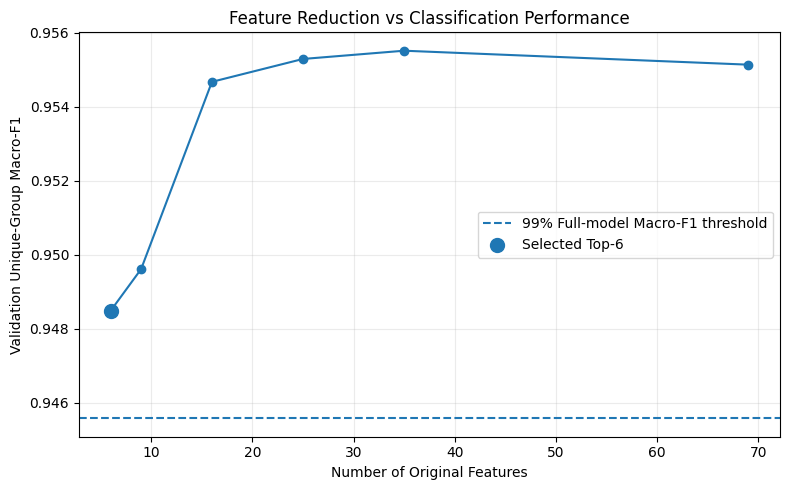

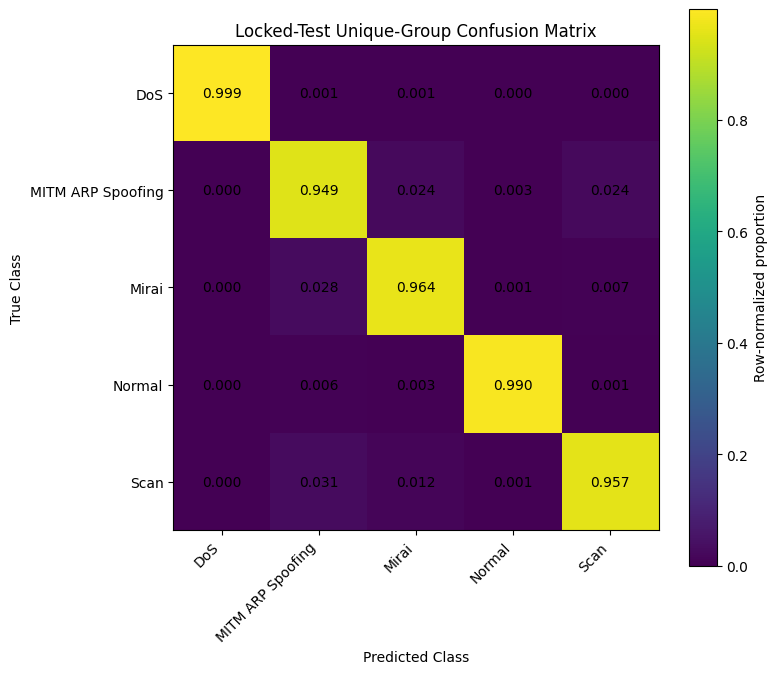

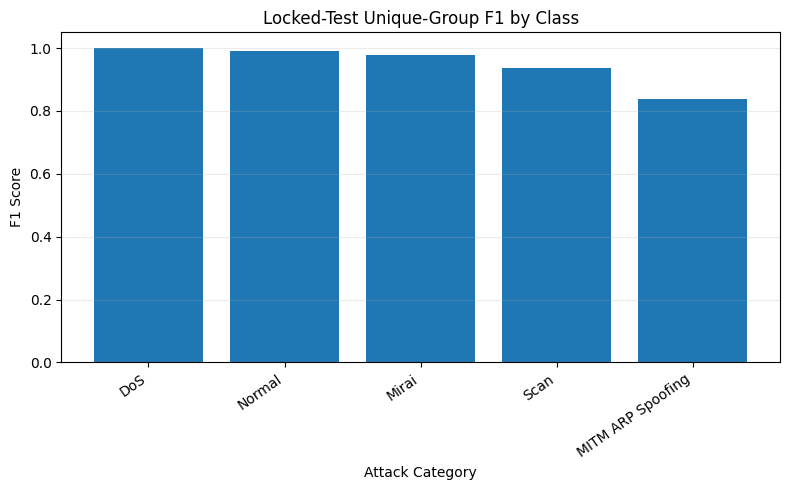

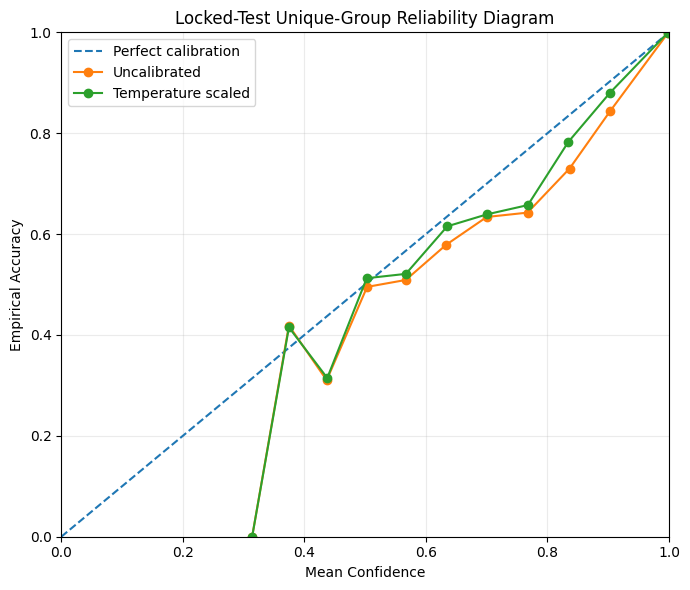


FINAL FIGURES SAVED
✅ /content/drive/MyDrive/iot project/reliable-iot-intrusion-detection/results/figures/feature_subset_macro_f1.png
✅ /content/drive/MyDrive/iot project/reliable-iot-intrusion-detection/results/figures/final_test_confusion_matrix_normalized.png
✅ /content/drive/MyDrive/iot project/reliable-iot-intrusion-detection/results/figures/final_test_class_f1.png
✅ /content/drive/MyDrive/iot project/reliable-iot-intrusion-detection/results/figures/final_test_reliability_diagram.png

✅ Final descriptive analysis completed.
✅ No model parameters were changed.
✅ Locked-test results were used only for final reporting.


In [ ]:
# ============================================================
# CELL 13 — FINAL RESULT FIGURES
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# PATHS
# ============================================================

FS_RESULTS_FILE = (
    TABLES_DIR /
    "xgboost_feature_subset_validation.csv"
)

FINAL_CM_FILE = (
    TABLES_DIR /
    "final_test_unique_group_confusion_matrix.csv"
)

FINAL_CLASS_RESULTS_FILE = (
    TABLES_DIR /
    "final_test_unique_group_class_metrics.csv"
)

FINAL_PREDICTIONS_FILE = (
    TABLES_DIR /
    "final_test_unique_group_predictions.csv"
)


# ============================================================
# 1. LOAD SAVED RESULTS
# ============================================================

fs_results = pd.read_csv(
    FS_RESULTS_FILE
)

cm_df = pd.read_csv(
    FINAL_CM_FILE,
    index_col=0
)

class_results = pd.read_csv(
    FINAL_CLASS_RESULTS_FILE
)

prediction_audit = pd.read_csv(
    FINAL_PREDICTIONS_FILE
)


print("✅ Saved results loaded.")


# ============================================================
# FIGURE 1
# FEATURE COUNT vs VALIDATION MACRO-F1
# ============================================================

plot_df = (
    fs_results
    .sort_values(
        "n_original_features"
    )
    .copy()
)

plt.figure(
    figsize=(8, 5)
)

plt.plot(
    plot_df[
        "n_original_features"
    ],
    plot_df[
        "macro_f1"
    ],
    marker="o"
)

plt.axhline(
    y=0.99 * 0.955136,
    linestyle="--",
    label="99% Full-model Macro-F1 threshold"
)

plt.scatter(
    [6],
    [
        plot_df.loc[
            plot_df[
                "n_original_features"
            ] == 6,
            "macro_f1"
        ].iloc[0]
    ],
    s=100,
    label="Selected Top-6"
)

plt.xlabel(
    "Number of Original Features"
)

plt.ylabel(
    "Validation Unique-Group Macro-F1"
)

plt.title(
    "Feature Reduction vs Classification Performance"
)

plt.grid(
    alpha=0.25
)

plt.legend()

plt.tight_layout()

FEATURE_SELECTION_FIG = (
    FIGURES_DIR /
    "feature_subset_macro_f1.png"
)

plt.savefig(
    FEATURE_SELECTION_FIG,
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()


# ============================================================
# FIGURE 2
# NORMALIZED CONFUSION MATRIX
# ============================================================

cm = cm_df.to_numpy(
    dtype=float
)

cm_normalized = (
    cm /
    cm.sum(
        axis=1,
        keepdims=True
    )
)


plt.figure(
    figsize=(8, 7)
)

image = plt.imshow(
    cm_normalized,
    interpolation="nearest"
)

plt.colorbar(
    image,
    label="Row-normalized proportion"
)

classes_plot = (
    cm_df.index.tolist()
)

plt.xticks(
    np.arange(
        len(classes_plot)
    ),
    classes_plot,
    rotation=45,
    ha="right"
)

plt.yticks(
    np.arange(
        len(classes_plot)
    ),
    classes_plot
)


for i in range(
    len(classes_plot)
):

    for j in range(
        len(classes_plot)
    ):

        plt.text(
            j,
            i,
            f"{cm_normalized[i, j]:.3f}",
            ha="center",
            va="center"
        )


plt.xlabel(
    "Predicted Class"
)

plt.ylabel(
    "True Class"
)

plt.title(
    "Locked-Test Unique-Group Confusion Matrix"
)

plt.tight_layout()

CM_FIG = (
    FIGURES_DIR /
    "final_test_confusion_matrix_normalized.png"
)

plt.savefig(
    CM_FIG,
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()


# ============================================================
# FIGURE 3
# PER-CLASS F1 SCORES
# ============================================================

class_plot_df = (
    class_results
    .sort_values(
        "f1",
        ascending=False
    )
)


plt.figure(
    figsize=(8, 5)
)

plt.bar(
    class_plot_df[
        "class"
    ],
    class_plot_df[
        "f1"
    ]
)

plt.ylim(
    0,
    1.05
)

plt.ylabel(
    "F1 Score"
)

plt.xlabel(
    "Attack Category"
)

plt.title(
    "Locked-Test Unique-Group F1 by Class"
)

plt.xticks(
    rotation=35,
    ha="right"
)

plt.grid(
    axis="y",
    alpha=0.25
)

plt.tight_layout()

CLASS_F1_FIG = (
    FIGURES_DIR /
    "final_test_class_f1.png"
)

plt.savefig(
    CLASS_F1_FIG,
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()


# ============================================================
# 4. RELIABILITY-DIAGRAM HELPER
# ============================================================

def reliability_bins(
    true_labels,
    predicted_labels,
    confidence,
    n_bins=15
):

    correct = (
        true_labels
        == predicted_labels
    ).astype(float)

    edges = np.linspace(
        0,
        1,
        n_bins + 1
    )

    rows = []

    for i in range(
        n_bins
    ):

        lower = edges[i]
        upper = edges[i + 1]

        if i == 0:

            mask = (
                (confidence >= lower)
                &
                (confidence <= upper)
            )

        else:

            mask = (
                (confidence > lower)
                &
                (confidence <= upper)
            )

        if mask.sum() == 0:
            continue

        rows.append({
            "mean_confidence":
                confidence[mask].mean(),

            "accuracy":
                correct[mask].mean(),

            "count":
                int(
                    mask.sum()
                )
        })

    return pd.DataFrame(
        rows
    )


# ============================================================
# 5. BUILD RELIABILITY DATA
# ============================================================

true_labels = (
    prediction_audit[
        "true_class"
    ].to_numpy()
)

predicted_labels = (
    prediction_audit[
        "predicted_class"
    ].to_numpy()
)

uncal_conf = (
    prediction_audit[
        "uncalibrated_confidence"
    ].to_numpy()
)

cal_conf = (
    prediction_audit[
        "calibrated_confidence"
    ].to_numpy()
)


uncal_reliability = (
    reliability_bins(
        true_labels,
        predicted_labels,
        uncal_conf,
        n_bins=15
    )
)

cal_reliability = (
    reliability_bins(
        true_labels,
        predicted_labels,
        cal_conf,
        n_bins=15
    )
)


# ============================================================
# FIGURE 4
# FINAL RELIABILITY DIAGRAM
# ============================================================

plt.figure(
    figsize=(7, 6)
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Perfect calibration"
)

plt.plot(
    uncal_reliability[
        "mean_confidence"
    ],
    uncal_reliability[
        "accuracy"
    ],
    marker="o",
    label="Uncalibrated"
)

plt.plot(
    cal_reliability[
        "mean_confidence"
    ],
    cal_reliability[
        "accuracy"
    ],
    marker="o",
    label="Temperature scaled"
)

plt.xlabel(
    "Mean Confidence"
)

plt.ylabel(
    "Empirical Accuracy"
)

plt.title(
    "Locked-Test Unique-Group Reliability Diagram"
)

plt.xlim(
    0,
    1
)

plt.ylim(
    0,
    1
)

plt.grid(
    alpha=0.25
)

plt.legend()

plt.tight_layout()

RELIABILITY_FIG = (
    FIGURES_DIR /
    "final_test_reliability_diagram.png"
)

plt.savefig(
    RELIABILITY_FIG,
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()


# ============================================================
# 6. SAVE RELIABILITY BIN TABLES
# ============================================================

uncal_reliability.to_csv(
    TABLES_DIR /
    "final_test_reliability_bins_uncalibrated.csv",
    index=False
)

cal_reliability.to_csv(
    TABLES_DIR /
    "final_test_reliability_bins_calibrated.csv",
    index=False
)


# ============================================================
# 7. CHECK SAVED FIGURES
# ============================================================

print("\n" + "=" * 90)
print("FINAL FIGURES SAVED")
print("=" * 90)

for path in [
    FEATURE_SELECTION_FIG,
    CM_FIG,
    CLASS_F1_FIG,
    RELIABILITY_FIG
]:

    print(
        "✅" if path.exists() else "❌",
        path
    )


print("\n✅ Final descriptive analysis completed.")
print("✅ No model parameters were changed.")
print("✅ Locked-test results were used only for final reporting.")